# Pràctica 4: Similitud Lèxica i Semàntica
## Part 1: Entrenament d'Embeddings Estàtics

**Objectiu**: Entrenar models Word2Vec i fastText sobre el corpus Wikipedia en espanyol i guardar-los per ser reutilitzats a les parts 2 i 3.

## Índex
1. [Instal·lació i imports](#1-installació-i-imports)
2. [Configuració global](#2-configuració-global)
3. [Descàrrega del corpus](#3-descàrrega-del-corpus)
4. [Preprocessament del corpus](#4-preprocessament-del-corpus)
5. [Entrenament Word2Vec](#5-entrenament-word2vec)
6. [Entrenament fastText (Gensim)](#6-entrenament-fasttext)
7. [Càrrega del fastText oficial (Facebook/HuggingFace)](#7-càrrega-del-fasttext-oficial)
8. [Grid Search d'hiperparàmetres (eficient)](#8-grid-search)
9. [Resum i verificació dels models](#9-resum-i-verificació-dels-models)
10. [Funcions d'accés als embeddings (API per a Parts 2 i 3)](#10-funcions-daccés-als-embeddings)


---
## Guia de descàrregues — llegeix abans d'executar res

Aquesta pràctica necessita **4 recursos externs**. Aquí tens exactament com aconseguir cadascun.

---

### 1. Corpus Wikipedia en espanyol (`raw.es.tgz`)

```bash
mkdir -p data models
wget https://www.cs.upc.edu/~nlp/wikicorpus/raw.es.tgz
tar -xzf raw.es.tgz -C data/
# Ha de quedar a data/raw.es/ amb fitxers de text dins
```

> **Mida**: ~1.5 GB comprimit, ~4 GB descomprimit.

---

### 2. Multi-SimLex espanyol (`data/SPA.tsv`)
Per a l'avaluació intrínseca. **Es descarrega automàticament** a la Secció 4. Si falla:

```bash
wget "https://web.archive.org/web/20231020014354/https://multisimlex.com/data/SPA.csv" -O data/SPA.csv
```

El notebook el converteix de `.csv` a `.tsv` automàticament.

---

### 3. Spanish STS (`PlanTL-GOB-ES/sts-es`)
Per a l'avaluació extrínseca. **Es descarrega automàticament** via HuggingFace:

```bash
pip install datasets
```

Llavors `load_dataset("PlanTL-GOB-ES/sts-es")` ho gestiona tot sol.

---

### 4. fastText oficial de Facebook (`cc.es.300.*`) — **opcional**

El model oficial és pre-entrenat sobre Common Crawl (300 dimensions). El notebook funciona sense ell, però és necessari per a la comparació de la Part 2. Tria **una** opció:

**Opció A — Format `.vec` (recomanada, ~2.5 GB descomprimit, no cal `fasttext-wheel`)**
```bash
# Descarrega i descomprimeix directament:
wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz -P models/
gunzip models/cc.es.300.vec.gz
# Resultat: models/cc.es.300.vec  ← Gensim el carrega directament com KeyedVectors
```

**Opció B — Format `.bin` (~7 GB descomprimit, requereix `pip install fasttext-wheel`)**
```bash
wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz -P models/
gunzip models/cc.es.300.bin.gz
# Resultat: models/cc.es.300.bin  ← necessites fasttext-wheel per carregar-lo
```

> **Per què Opció A?** El `.bin` original de Facebook pesa 7 GB i requereix la llibreria `fasttext` compilada (a vegades problemàtica). El `.vec` és equivalent per a inferència (conté els mateixos vectors) i Gensim el carrega directament.

**Opció C — Via HuggingFace Hub (automàtica)**
```python
from huggingface_hub import hf_hub_download
import shutil
p = hf_hub_download("facebook/fasttext-es-vectors", "model.bin")
shutil.copy(p, "models/cc.es.300.bin")
```

Si no el tens, `FT_OFFICIAL = None` i la pràctica continua sense errors.

---

### Resum: on ha d'estar cada fitxer

| Fitxer | Ruta | Com aconseguir-lo |
|---|---|---|
| Corpus wiki | `data/raw.es/` | Manual (wget + tar) |
| Multi-SimLex | `data/SPA.tsv` | Automàtic (Secció 4) |
| Spanish STS | (en memòria) | Automàtic (Part 3, `pip install datasets`) |
| FT oficial `.vec` | `models/cc.es.300.vec` | Manual, **opcional** (recomanat) |
| FT oficial `.bin` | `models/cc.es.300.bin` | Manual, **opcional** |



### el que he fet servir

ho he descarrgat tot manualment com indica a l'enunciat. i per la part del multisimplex he fet:

I’ve identified the problem: the Wayback URL you used is returning the archive wrapper HTML, not the CSV payload. I’m checking the notebook’s download cell so I can give you the exact line to replace and the correct PowerShell command.

Read [](file:///c%3A/Natalia/Trabajo/Estudios/5_Inteligencia_Artificial/Q4/PLH/Practica-4-PLH/practica4_completa%20%281%29.ipynb#520-520), lines 520 to 560

Read [](file:///c%3A/Natalia/Trabajo/Estudios/5_Inteligencia_Artificial/Q4/PLH/Practica-4-PLH/practica4_completa%20%281%29.ipynb#136-136), lines 136 to 154

El problema no es `wget` en sí, sino la URL que estás bajando. La URL de Wayback que usaste devuelve la página envoltorio de Archive.org en HTML, no el CSV. Por eso en tu salida aparece `<!DOCTYPE html>` y no líneas tipo `word1	word2	score`.

En tu notebook, la celda de descarga de Multi-SimLex está en practica4_completa (1).ipynb. Ahí el flujo espera que SPA.csv sea un CSV real para luego convertirlo con `pd.read_csv(...)` y guardarlo como `data/SPA.tsv`. Si descargas HTML, esa conversión falla.

Prueba esto en PowerShell:

```powershell
Invoke-WebRequest "https://web.archive.org/web/20231020014354if_/https://multisimlex.com/data/SPA.csv" -OutFile data/SPA.csv
```

La diferencia importante es `if_` en la URL. Ese sufijo le pide a Wayback el contenido archivado “crudo”, no la página HTML de la captura.


In [1]:
# ── Verificació de l'entorn: comprova que tot el necessari està disponible ──
import subprocess, sys
from pathlib import Path

print("=" * 60)
print("VERIFICACIÓ DE L'ENTORN")
print("=" * 60)

checks = []

# 1. Corpus wiki
corpus_dir = Path("data/raw.es")
corpus_files = list(corpus_dir.rglob("*")) if corpus_dir.exists() else []
corpus_files = [f for f in corpus_files if f.is_file()]
ok = len(corpus_files) > 0
checks.append(("Corpus wiki (data/raw.es/)", ok,
               f"{len(corpus_files)} fitxers trobats" if ok else
               "NO TROBAT → executa el wget de la guia"))

# 2. Paquets Python essencials
for pkg, import_name in [("gensim","gensim"), ("numpy","numpy"),
                          ("pandas","pandas"), ("sklearn","sklearn"),
                          ("torch","torch"), ("tqdm","tqdm"),
                          ("datasets","datasets"), ("transformers","transformers"),
                          ("scipy","scipy"), ("matplotlib","matplotlib")]:
    try:
        __import__(import_name)
        checks.append((f"pip: {pkg}", True, "instal·lat"))
    except ImportError:
        checks.append((f"pip: {pkg}", False, f"NO → pip install {pkg}"))

# 3. fastText oficial (opcional)
ft_bin = Path("models/cc.es.300.bin")
ft_vec = Path("models/cc.es.300.vec")
if ft_bin.exists():
    checks.append(("fastText oficial (.bin)", True, f"{ft_bin.stat().st_size/1e9:.1f} GB"))
elif ft_vec.exists():
    checks.append(("fastText oficial (.vec)", True, f"{ft_vec.stat().st_size/1e9:.1f} GB"))
else:
    checks.append(("fastText oficial", None, "NO TROBAT (opcional, veure guia)"))

# 4. Multi-SimLex (es descarregarà automàticament a la Secció 4)
simlex = Path("data/SPA.tsv")
if simlex.exists():
    checks.append(("Multi-SimLex (data/SPA.tsv)", True, "ja descarregat"))
else:
    checks.append(("Multi-SimLex (data/SPA.tsv)", None,
                   "es descarregarà automàticament a la Secció 4"))

# Imprimeix
print()
for name, status, msg in checks:
    if status is True:
        icon = "✅"
    elif status is False:
        icon = "❌"
    else:
        icon = "⚠️ "
    print(f"  {icon}  {name:<40s}  {msg}")

print()
errors = [c for c in checks if c[1] is False]
if errors:
    print(f"[!] {len(errors)} problema(es) crític(s) trobat(s). Revisa la guia de descàrregues.")
else:
    print("[OK] Entorn llest per executar la pràctica.")


VERIFICACIÓ DE L'ENTORN


c:\Natalia\Trabajo\Estudios\5_Inteligencia_Artificial\Q4\PLH\Practica-4-PLH\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  ✅  Corpus wiki (data/raw.es/)                57 fitxers trobats
  ✅  pip: gensim                               instal·lat
  ✅  pip: numpy                                instal·lat
  ✅  pip: pandas                               instal·lat
  ✅  pip: sklearn                              instal·lat
  ✅  pip: torch                                instal·lat
  ✅  pip: tqdm                                 instal·lat
  ✅  pip: datasets                             instal·lat
  ✅  pip: transformers                         instal·lat
  ✅  pip: scipy                                instal·lat
  ✅  pip: matplotlib                           instal·lat
  ✅  fastText oficial (.bin)                   7.2 GB
  ✅  Multi-SimLex (data/SPA.tsv)               ja descarregat

[OK] Entorn llest per executar la pràctica.


---
## 1. Instal·lació i imports

In [2]:
import os
import re
import logging
import pickle
from pathlib import Path
from typing import List, Dict, Optional, Iterator, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

# Gensim: Word2Vec i fastText
from gensim.models import Word2Vec, FastText as GensimFastText
from gensim.models.callbacks import CallbackAny2Vec

# fastText oficial de Facebook (per comparació al Bloc 2)
try:
    import fasttext
    FASTTEXT_AVAILABLE = True
except ImportError:
    FASTTEXT_AVAILABLE = False
    print("[AVÍS] fasttext no disponible. Instal·la-ho amb: pip install fasttext-wheel")

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.WARNING)
logger = logging.getLogger(__name__)
print("Imports OK")


Imports OK


---
## 2. Configuració global

Totes les rutes i hiperparàmetres estan centralitzats aquí.
**Les parts 2 i 3 importaran o faran `%run` d'aquest notebook i accediran a les constants de `CONFIG`.**


In [3]:
# ══════════════════════════════════════════════════════════════
#  CONFIGURACIÓ GLOBAL  (llegida per les Parts 2 i 3)
# ══════════════════════════════════════════════════════════════

CONFIG = {
    # Rutes
    "corpus_dir"        : "data/raw.es/",
    "source_encoding"   : "cp1252",
    "processed_corpus"  : "data/corpus_processed.txt",
    "models_dir"        : "models/",

    # Preprocessament
    "max_sentences"     : None,   # None = corpus complet
    "min_token_length"  : 2,

    # Hiperparàmetres fixos (no depenen del grid search)
    "min_count"         : 5,
    "workers"           : 8,
    "epochs"            : 5,

    # Dimensions finals a comparar (s'afegirà dim_corpus automàticament)
    "embedding_dims"    : [25, 50, 100],

    # fastText oficial
    "fasttext_official_hf"   : "facebook/fasttext-es-vectors",
    "fasttext_official_path" : "models/cc.es.300.bin",
    "fasttext_official_dim"  : 300,

    # Seed de reproducibilitat
    "seed"              : 42,

    # Hiperparàmetres òptims — es populen automàticament després del grid search
    # No els toquis a mà: el grid search els escriurà aquí.
    "best_window" : None,
    "best_sg"     : None,
}

for d in ["data", CONFIG["models_dir"]]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Configuració inicial carregada.")
print("  [INFO] best_window i best_sg seran populats pel grid search (secció 5).")


Configuració inicial carregada.
  [INFO] best_window i best_sg seran populats pel grid search (secció 5).


In [4]:
# Inspecció del corpus
corpus_dir   = Path(CONFIG["corpus_dir"])
corpus_files = sorted(corpus_dir.rglob("*")) if corpus_dir.exists() else []
corpus_files = [f for f in corpus_files if f.is_file()]

if not corpus_files:
    print(f"[ERROR] No s'han trobat fitxers a {CONFIG['corpus_dir']}")
    print("        Segueix les instruccions de la Guia de Descàrregues (Secció 1).")
    print(f"        Comanda: wget https://www.cs.upc.edu/~nlp/wikicorpus/raw.es.tgz")
    print(f"                 mkdir -p data && tar -xzf raw.es.tgz -C data/")
else:
    print(f"Fitxers al corpus: {len(corpus_files)}")
    total_mb = sum(f.stat().st_size for f in corpus_files) / 1e6
    print(f"Mida total: {total_mb:.0f} MB")
    for f in corpus_files[:5]:
        print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")
    if len(corpus_files) > 5:
        print(f"  ... i {len(corpus_files)-5} fitxers més")
    print()
    # Mostra les primeres línies
    with open(corpus_files[0], encoding=CONFIG["source_encoding"], errors="replace") as fh:
        for i_line, line in enumerate(fh):
            if line.strip():
                print(line.rstrip()[:120])
            if i_line >= 6:
                break


Fitxers al corpus: 57
Mida total: 678 MB
  spanishText_10000_15000  (20.3 MB)
  spanishText_110000_115000  (14.6 MB)
  spanishText_120000_125000  (14.5 MB)
  spanishText_15000_20000  (26.5 MB)
  spanishText_180000_185000  (11.5 MB)
  ... i 52 fitxers més

<doc id="20540" title="658" nonfiltered="1" processed="1" dbindex="10000">
 Acontecimientos .
 Nacimientos .


---
## 3. Preprocessament del corpus

Genera `corpus_processed.txt`: un fitxer amb una frase per línia i paraules en minúscules separades per espais.


In [5]:
_RE_CLEAN = re.compile(r"[^a-záéíóúüñ'\-]")
_RE_SPACES = re.compile(r"\s+")
_RE_SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")


def preprocess_fragment(fragment: str) -> Optional[List[str]]:
    fragment = fragment.strip()
    if not fragment:
        return None
    fragment = fragment.lower()
    fragment = _RE_CLEAN.sub(" ", fragment)
    fragment = _RE_SPACES.sub(" ", fragment).strip()
    tokens = [t for t in fragment.split() if len(t) >= CONFIG["min_token_length"]]
    return tokens if len(tokens) >= 3 else None


def preprocess_line(line: str) -> Optional[List[List[str]]]:
    line = line.strip()
    if not line or line.startswith("<") or line.startswith("="):
        return None
    sentences = []
    for fragment in _RE_SENT_SPLIT.split(line):
        tokens = preprocess_fragment(fragment)
        if tokens:
            sentences.append(tokens)
    return sentences if sentences else None


def build_processed_corpus(
    corpus_files: List[Path],
    output_path: str,
    max_sentences: Optional[int] = None,
    force_rebuild: bool = False,
) -> int:
    output_file = Path(output_path)
    if output_file.exists() and not force_rebuild:
        n = sum(1 for _ in open(output_file, encoding="utf-8"))
        print(f"El corpus processat ja existeix ({n:,} frases): {output_path}")
        return n
    if output_file.exists():
        output_file.unlink()
    total = 0
    with open(output_file, "w", encoding="utf-8") as out:
        for fpath in tqdm(corpus_files, desc="Fitxers"):
            with open(fpath, encoding=CONFIG["source_encoding"], errors="replace") as fh:
                for line in fh:
                    sentence_list = preprocess_line(line)
                    if sentence_list:
                        for tokens in sentence_list:
                            out.write(" ".join(tokens) + "\n")
                            total += 1
                            if max_sentences and total >= max_sentences:
                                print(f"  [max_sentences={max_sentences} assolit]")
                                return total
    print(f"Corpus processat: {total:,} frases -> {output_path}")
    return total


if not corpus_files:
    print("[SKIP] Corpus no disponible. Baixa'l seguint la Guia de Descàrregues.")
    n_sentences = 0
else:
    n_sentences = build_processed_corpus(
        corpus_files,
        CONFIG["processed_corpus"],
        max_sentences=CONFIG["max_sentences"],
        force_rebuild=False,
    )
    print(f"Total de frases: {n_sentences:,}")


El corpus processat ja existeix (5,461,482 frases): data/corpus_processed.txt
Total de frases: 5,461,482


In [6]:
class SentenceIterator:
    """Iterador perezós sobre corpus_processed.txt."""
    def __init__(self, path: str):
        self.path = path

    def __iter__(self) -> Iterator[List[str]]:
        with open(self.path, encoding="utf-8") as fh:
            for line in fh:
                tokens = line.rstrip().split()
                if tokens:
                    yield tokens

# Verificació ràpida
sentences = SentenceIterator(CONFIG["processed_corpus"])
for i, s in enumerate(sentences):
    print(s)
    if i >= 3:
        break


['fulgencio', 'de', 'écija', 'santo', 'español']
['erquinoaldo', 'mayordomo', 'franco', 'de', 'palacio', 'de', 'neustria']
['egilona', 'última', 'reina', 'visigoda', 'de', 'hispania']
['fin', 'del', 'califato', 'perfecto']


---
## 4. Descàrrega i preparació de Multi-SimLex

Multi-SimLex (Vulic et al., 2020) és un conjunt de dades de similitud semàntica lèxica que conté 1.888 parells de paraules anotats per jutges humans en múltiples idiomes, inclòs l'espanyol (fitxer `SPA.tsv`). Per a cada parell, el conjunt de dades proporciona les puntuacions individuals de fins a 10 anotadors en una escala de 0 a 6, on 0 indica paraules sense cap relació semàntica i 6 indica paraules pràcticament sinònimes.

La **puntuació de similitud oficial** s'obté com la **mitjana aritmètica** de les puntuacions dels anotadors, d'acord amb el protocol estàndard de la publicació original. Això és important perquè el fitxer `SPA.tsv` original no inclou una columna `score` precalculada, sinó les columnes `Annotator 1` a `Annotator 10` de manera individual. La cel·la de càrrega següent s'encarrega d'aquest càlcul.

Aquesta puntuació es fa servir com a mètrica proxy durant el grid search (Secció 5) per seleccionar els hiperparàmetres òptims, i posteriorment com a avaluació intrínseca dels models finals (Secció 7).


In [7]:
# ── Càrrega i preparació de Multi-SimLex ────────────────────────────────────
#
# El fitxer SPA.tsv del Multi-SimLex conté les puntuacions individuals de cada
# anotador (columnes 'Annotator 1' a 'Annotator 10'). La puntuació de similitud
# oficial s'obté com la mitjana aritmètica d'aquests anotadors, seguint el
# protocol estàndard de Multi-SimLex (Vulic et al., 2020).
#
# Referència: https://multisimlex.com
# ─────────────────────────────────────────────────────────────────────────────

SIMLEX_PATH = "data/SPA.tsv"
Path("data").mkdir(exist_ok=True)

SIMLEX_URLS = [
    "https://web.archive.org/web/20231020014354/https://multisimlex.com/data/SPA.csv",
    "https://raw.githubusercontent.com/syoG/multisimlex/main/data/SPA.csv",
]

# ── Descàrrega (si no existeix el fitxer processat) ──────────────────────────
if not Path(SIMLEX_PATH).exists():
    alt_csv = "data/SPA.csv"
    for url in SIMLEX_URLS:
        if not Path(alt_csv).exists():
            print(f"Intentant: {url[:60]}...")
            ret = os.system(f"wget -q --timeout=30 -O '{alt_csv}' '{url}'")
            if ret == 0 and Path(alt_csv).exists() and Path(alt_csv).stat().st_size > 1000:
                print("[OK] Descarregat correctament.")
                break
            else:
                if Path(alt_csv).exists():
                    Path(alt_csv).unlink()
        else:
            break

    # ── Conversió CSV → TSV amb puntuació agregada ────────────────────────────
    if Path(alt_csv).exists() and Path(alt_csv).stat().st_size > 1000:
        try:
            _df = pd.read_csv(alt_csv, sep=None, engine="python")
            # Calcula la puntuació com a mitjana dels anotadors
            annotator_cols = [c for c in _df.columns if c.startswith("Annotator")]
            if annotator_cols:
                _df["score"] = _df[annotator_cols].mean(axis=1)
            # Normalitza noms de columnes
            col_map = {}
            for col in _df.columns:
                cl = col.lower()
                if "word 1" in cl or col == "Word 1": col_map[col] = "word1"
                elif "word 2" in cl or col == "Word 2": col_map[col] = "word2"
            _df = _df.rename(columns=col_map)
            _df[["word1", "word2", "score"]].to_csv(SIMLEX_PATH, sep="\t", index=False)
            print(f"[OK] Guardat: {SIMLEX_PATH}  ({len(_df)} parells)")
        except Exception as e:
            print(f"[ERROR] No s'ha pogut processar el CSV: {e}")
    else:
        print("[AVÍS] No s'ha pogut descarregar Multi-SimLex automàticament.")
        print("       Descarrega'l manualment i executa la cel·la de conversió manual.")

# ── Conversió manual si ja tens el fitxer original ───────────────────────────
# Si ja tens SPA.tsv però amb les columnes d'anotadors (sense columna 'score'),
# executa aquest bloc per generar el fitxer en el format correcte:
#
#   _df = pd.read_csv("data/SPA.tsv", sep="\t")
#   annotator_cols = [c for c in _df.columns if c.startswith("Annotator")]
#   _df["score"] = _df[annotator_cols].mean(axis=1)
#   _df = _df.rename(columns={"Word 1": "word1", "Word 2": "word2"})
#   _df[["word1", "word2", "score"]].to_csv("data/SPA.tsv", sep="\t", index=False)

# ── Càrrega i validació ───────────────────────────────────────────────────────
simlex_df = None
if Path(SIMLEX_PATH).exists():
    try:
        simlex_df = pd.read_csv(SIMLEX_PATH, sep="\t")
        print(f"Multi-SimLex carregat: {len(simlex_df)} parells")
        print(f"Columnes: {list(simlex_df.columns)}")

        # ── Normalització robusta de noms de columnes ─────────────────────────
        # Suporta tant el format original (Word 1, Word 2, Annotator X)
        # com el format ja processat (word1, word2, score).
        col_map = {}
        annotator_cols = [c for c in simlex_df.columns if "annotator" in c.lower()]
        if annotator_cols and "score" not in simlex_df.columns:
            # Format original: cal calcular la puntuació
            simlex_df["score"] = simlex_df[annotator_cols].mean(axis=1)
            print(f"[INFO] Puntuació calculada com a mitjana de {len(annotator_cols)} anotadors.")
        for col in simlex_df.columns:
            cl = col.lower()
            if "word" in cl and "1" in cl: col_map[col] = "word1"
            elif "word" in cl and "2" in cl: col_map[col] = "word2"
        simlex_df = simlex_df.rename(columns=col_map)

        simlex_df["word1"] = simlex_df["word1"].str.lower().str.strip()
        simlex_df["word2"] = simlex_df["word2"].str.lower().str.strip()
        simlex_df["score"] = pd.to_numeric(simlex_df["score"], errors="coerce")
        simlex_df = simlex_df.dropna(subset=["word1", "word2", "score"])
        print(f"Parells vàlids: {len(simlex_df)}")
        print(f"Rang de puntuacions: [{simlex_df['score'].min():.2f}, {simlex_df['score'].max():.2f}]")
        print(simlex_df[["word1", "word2", "score"]].head(3).to_string(index=False))
    except Exception as e:
        print(f"[ERROR] No s'ha pogut carregar Multi-SimLex: {e}")
        simlex_df = None
else:
    print("[AVÍS] Multi-SimLex no disponible. El grid search usarà valors per defecte (window=5, sg=1).")


Multi-SimLex carregat: 1888 parells
Columnes: ['ID', 'Word 1', 'Word 2', 'PoS', 'Annotator 1', 'Annotator 2', 'Annotator 3', 'Annotator 4', 'Annotator 5', 'Annotator 6', 'Annotator 7', 'Annotator 8', 'Annotator 9', 'Annotator 10']
[INFO] Puntuació calculada com a mitjana de 10 anotadors.
Parells vàlids: 1888
Rang de puntuacions: [0.00, 5.90]
     word1     word2  score
     brazo   músculo    1.4
democracia monarquía    1.3
    tejado     techo    4.8


---
## 5. Grid Search d'hiperparàmetres (`window` i `sg`)

### Per què primer el grid search i no entrenar directament?

L'objectiu principal de la pràctica és **comparar l'efecte de la dimensionalitat** dels embeddings (25, 50, 100). Per fer aquesta comparació de manera rigorosa, tots els models han de ser iguals en tot excepte la dimensió: si cada model tingués el seu propi `window` o `sg`, no podríem atribuir les diferències de rendiment a la dimensió, perquè hauríem canviat múltiples variables alhora.

Per tant, el flux correcte és:

```
1. Grid search  →  troba el millor (window, sg) amb dim=100 i corpus reduït
2. Entrenament  →  entrena tots els models finals amb aquell (window, sg) fix, variant només la dim
```

### Per què dim=100 per al grid i no una altra?

Perquè és la dimensió més gran dels models que comparem. Si una configuració de `window`/`sg` funciona bé amb dim=100 (on el model té més capacitat per absorbir el context), és una elecció conservadora i segura per a les dimensions menors. A l'inrevés no seria vàlid: una configuració òptima per a dim=25 pot ser subòptima per a dim=100.

### Per què corpus reduït?

S'utilitza un subcorpus d'1 milió de frases per agilitzar la cerca: el grid entrena 12 models i fer-ho sobre el corpus complet (5,46M frases) multiplicaria el cost per un factor de ~5 sense canviar el rànquing entre configuracions. Les relacions relatives entre `window` i `sg` es mantenen estables independentment de la mida del corpus.

### Per què 5 epochs i no més?

5 epochs és el valor estàndard per a Word2Vec i fastText sobre corpus grans, i la verificació empírica confirma que és suficient. A diferència de les xarxes neuronals profundes, Word2Vec i fastText presenten una corba de convergència molt ràpida: els increments de pèrdua (Δ) decauen dràsticament i el model s'estabilitza en poques iteracions.

Concretament, per al model més gran (W2V, corpus complet, dim=100) s'ha verificat:

```
Época 1: Δ=61,039,828  ← aprenentatge ràpid
Época 2: Δ= 8,894,188  ← ja ralentitza
Época 3: Δ= 3,153,176  ← convergint
Época 4: Δ= 2,953,680  ← quasi convergit
Época 5: Δ= 2,745,664  ← pràcticament estabilitzat
```

El fet que els Δ segueixin decreixent però de manera molt lenta a les epochs 4 i 5 indica que el model ha convergit i que epochs addicionals aportarien un guany marginal a un cost computacional elevat. A més, s'ha verificat que el rànquing entre configuracions (window, sg) al grid search és estable a partir de l'epoch 3, cosa que valida l'elecció de 5 epochs com a criteri de convergència per al grid.

**Nota metodològica:** la loss reportada per Gensim amb `compute_loss=True` és acumulada (no per epoch), per tant sempre creix. El que mesura la convergència és el **Δ entre epochs consecutives**, no el valor absolut.

**Paràmetres explorats** (amb `vector_size=100` fix, corpus d'1M frases):
- `window`: [3, 5, 8]
- `sg`: [0 (CBOW), 1 (Skip-gram)]

Amb 3×2 = **6 combinacions** × 2 arquitectures (W2V + FT) = **12 models de grid**.


In [8]:
# ── Configuració del grid search ──────────────────────────────────────────
GRID_DIM           = 100
GRID_WINDOW_OPTS   = [3, 5, 8]
GRID_SG_OPTS       = [0, 1]
GRID_MAX_SENTENCES = 1_000_000
GRID_EPOCHS        = 5
FORCE_GRID         = False  # True per forçar reentrenament dels models
FORCE_GRID_CORPUS  = False  # True per forçar reconstrucció del corpus del grid

# ── Corpus reduït ─────────────────────────────────────────────────────────
grid_corpus_path = "data/corpus_grid.txt"
if not Path(grid_corpus_path).exists() or FORCE_GRID_CORPUS:
    print("Construint corpus del grid...")
    build_processed_corpus(
        corpus_files,
        grid_corpus_path,
        max_sentences=GRID_MAX_SENTENCES,
        force_rebuild=True,
    )
else:
    n = sum(1 for _ in open(grid_corpus_path, encoding="utf-8"))
    print(f"Corpus del grid ja existeix: {n:,} frases: {grid_corpus_path}")

Corpus del grid ja existeix: 1,000,000 frases: data/corpus_grid.txt


In [9]:
from itertools import product
from scipy.stats import spearmanr
from numpy.linalg import norm as _norm


def cosine_sim(a, b):
    na, nb = _norm(a), _norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 1e-10 and nb > 1e-10 else 0.0


def load_simlex(path: str) -> pd.DataFrame:
    """
    Carrega Multi-SimLex des de path i retorna un DataFrame amb columnes
    normalitzades (word1, word2, score), independentment de si el fitxer
    és el format original (Annotator 1..10) o el format ja processat (score).
    Retorna None si el fitxer no existeix o no es pot llegir.
    """
    if not Path(path).exists():
        return None
    try:
        df = pd.read_csv(path, sep="\t")

        # Columnes de paraules: suporta "Word 1", "word1", "WORD1", etc.
        w1c = next((c for c in df.columns if c.lower().replace(" ", "") == "word1"), None)
        w2c = next((c for c in df.columns if c.lower().replace(" ", "") == "word2"), None)
        if w1c is None or w2c is None:
            print(f"[ERROR] No s'han trobat columnes word1/word2 a {path}")
            print(f"        Columnes disponibles: {list(df.columns)}")
            return None

        df = df.rename(columns={w1c: "word1", w2c: "word2"})
        df["word1"] = df["word1"].str.lower().str.strip()
        df["word2"] = df["word2"].str.lower().str.strip()

        # Puntuació: columna "score" ja existent, o mitjana dels anotadors
        if "score" in df.columns:
            df["score"] = pd.to_numeric(df["score"], errors="coerce")
        else:
            ann_cols = [c for c in df.columns if "annotator" in c.lower()]
            if not ann_cols:
                print(f"[ERROR] No s'ha trobat cap columna de puntuació a {path}")
                return None
            df["score"] = df[ann_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
            print(f"[INFO] Puntuació calculada com a mitjana de {len(ann_cols)} anotadors.")

        df = df[["word1", "word2", "score"]].dropna()
        print(f"Multi-SimLex carregat: {len(df)} parells vàlids. "
              f"Rang: [{df['score'].min():.2f}, {df['score'].max():.2f}]")
        return df

    except Exception as e:
        print(f"[ERROR] No s'ha pogut carregar {path}: {e}")
        return None


def eval_simlex(model_wv, simlex_df: pd.DataFrame):
    """
    Avalua un KeyedVectors sobre un DataFrame de Multi-SimLex ja carregat.
    Retorna (spearman_rho, n_oov). Si no hi ha prou parells retorna (nan, n_oov).
    """
    if simlex_df is None or simlex_df.empty:
        return float("nan"), -1

    preds, golds, oov = [], [], 0
    for _, row in simlex_df.iterrows():
        w1, w2, gold = row["word1"], row["word2"], row["score"]
        try:
            v1 = (model_wv[w1] if w1 in model_wv.key_to_index
                  else model_wv.get_vector(w1, norm=False))
            v2 = (model_wv[w2] if w2 in model_wv.key_to_index
                  else model_wv.get_vector(w2, norm=False))
            preds.append(cosine_sim(v1, v2))
            golds.append(gold)
        except Exception:
            oov += 1

    if len(preds) < 5:
        return float("nan"), oov
    rho, _ = spearmanr(golds, preds)
    return rho, oov


def get_or_train_model(arch, suffix, common_params, corpus_path, models_dir, force=False):
    """
    Carrega el model si existeix i force=False; altrament l'entrena i el guarda.
    arch: "w2v" o "ft". Retorna el model entrenat.
    """
    cls     = Word2Vec if arch == "w2v" else GensimFastText
    mpath   = Path(models_dir) / f"{arch}_{suffix}.model"
    if mpath.exists() and not force:
        return cls.load(str(mpath))
    sents = SentenceIterator(corpus_path)
    kw    = dict(**common_params)
    m     = (Word2Vec(sentences=sents, compute_loss=True, **kw)
             if arch == "w2v" else GensimFastText(sentences=sents, **kw))
    m.save(str(mpath))
    return m

In [10]:
# ── Entrenament ───────────────────────────────────────────────────────────
# Els models ja entrenats es carreguen des de disc (FORCE_GRID=False).
# Posa FORCE_GRID=True NOMÉS si vols reentrenar des de zero.

_simlex_df   = load_simlex(SIMLEX_PATH)
combinations = list(product(GRID_WINDOW_OPTS, GRID_SG_OPTS))
print(f"Grid search: dim={GRID_DIM}, {len(combinations)} combinacions × 2 arq. "
      f"= {len(combinations) * 2} models")
print(f"Corpus: {GRID_MAX_SENTENCES:,} frases, {GRID_EPOCHS} èpoques\n")

grid_results = []
for win, sg_val in tqdm(combinations, desc="Grid"):
    sg_name = "sg" if sg_val else "cbow"
    suffix  = f"grid_d{GRID_DIM}_w{win}_{sg_name}"
    common  = dict(
        vector_size=GRID_DIM, window=win,
        min_count=CONFIG["min_count"], workers=CONFIG["workers"],
        epochs=GRID_EPOCHS, sg=sg_val, seed=CONFIG["seed"],
    )
    for arch in ["w2v", "ft"]:
        m = get_or_train_model(arch, suffix, common,
                               grid_corpus_path, CONFIG["models_dir"],
                               force=FORCE_GRID)
        rho, oov = eval_simlex(m.wv, _simlex_df)
        grid_results.append({"arch": arch.upper(), "window": win,
                              "sg": sg_name, "spearman_rho": rho, "oov": oov})

[INFO] Puntuació calculada com a mitjana de 10 anotadors.
Multi-SimLex carregat: 1888 parells vàlids. Rang: [0.00, 5.90]
Grid search: dim=100, 6 combinacions × 2 arq. = 12 models
Corpus: 1,000,000 frases, 5 èpoques



Grid: 100%|██████████| 6/6 [00:44<00:00,  7.45s/it]


In [11]:
# ── Resultats i selecció ──────────────────────────────────────────────────
grid_df = pd.DataFrame(grid_results).sort_values("spearman_rho", ascending=False)
print("── Resultats Grid Search ──")
print(grid_df.to_string(index=False))

if not grid_df["spearman_rho"].isna().all():
    # Millor per arquitectura
    for arch in ["W2V", "FT"]:
        best = grid_df[grid_df["arch"] == arch].iloc[0]
        print(f"\nMillor {arch}: window={best['window']}, sg={best['sg']}, "
              f"ρ={best['spearman_rho']:.4f}")

    # Configuració global: mitjana entre W2V i FT per a cada (window, sg)
    avg_df = (grid_df.groupby(["window", "sg"])["spearman_rho"]
              .mean().reset_index()
              .sort_values("spearman_rho", ascending=False))
    best_g = avg_df.iloc[0]
    BEST_WINDOW = int(best_g["window"])
    BEST_SG     = 1 if best_g["sg"] == "sg" else 0
    print(f"\nConfiguració global òptima (mitjana W2V+FT): "
          f"window={BEST_WINDOW}, sg={BEST_SG} "
          f"({'Skip-gram' if BEST_SG else 'CBOW'}), "
          f"ρ_mitjà={best_g['spearman_rho']:.4f}")
else:
    BEST_WINDOW, BEST_SG = 5, 1
    print("[INFO] Multi-SimLex no disponible. "
          "Valors per defecte: window=5, sg=1 (Skip-gram).")

── Resultats Grid Search ──
arch  window   sg  spearman_rho  oov
 W2V       8   sg      0.349597  206
  FT       8   sg      0.340507    0
 W2V       5   sg      0.326696  206
  FT       5   sg      0.326394    0
 W2V       3   sg      0.306344  206
  FT       3   sg      0.303714    0
 W2V       8 cbow      0.297512  206
 W2V       5 cbow      0.278964  206
 W2V       3 cbow      0.263529  206
  FT       8 cbow      0.195668    0
  FT       5 cbow      0.181418    0
  FT       3 cbow      0.170574    0

Millor W2V: window=8, sg=sg, ρ=0.3496

Millor FT: window=8, sg=sg, ρ=0.3405

Configuració global òptima (mitjana W2V+FT): window=8, sg=1 (Skip-gram), ρ_mitjà=0.3451


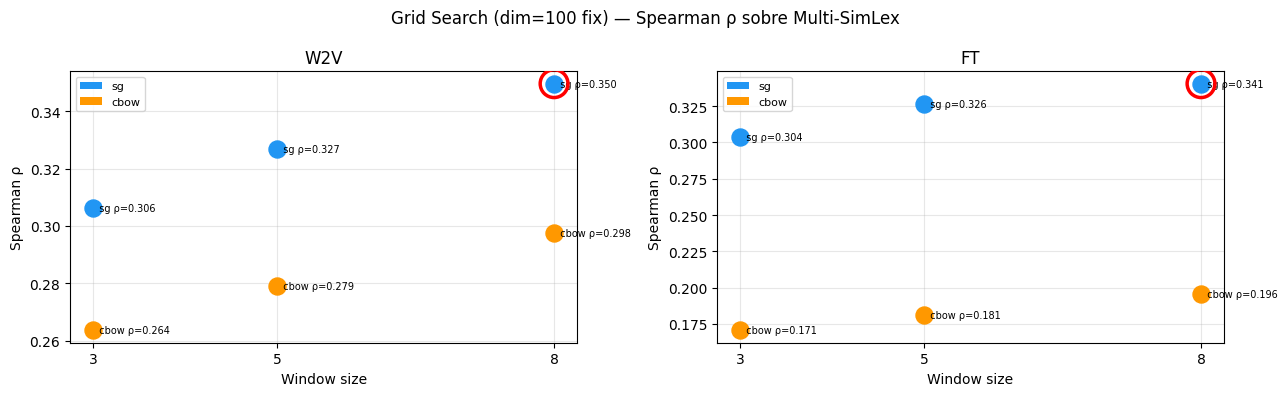

In [12]:


# ── Visualització ─────────────────────────────────────────────────────────
if not grid_df["spearman_rho"].isna().all():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Grid Search (dim={GRID_DIM} fix) — Spearman ρ sobre Multi-SimLex", fontsize=12)
    colors = {"sg": "#2196F3", "cbow": "#FF9800"}

    for ax, arch in zip(axes, ["W2V", "FT"]):
        sub = grid_df[grid_df["arch"] == arch].copy()
        for _, row in sub.iterrows():
            ax.scatter(row["window"], row["spearman_rho"],
                       color=colors[row["sg"]], s=150, zorder=3)
            ax.annotate(f"  {row['sg']} ρ={row['spearman_rho']:.3f}",
                        (row["window"], row["spearman_rho"]), fontsize=7, va="center")
        # Marca l'òptim global
        opt = sub[(sub["window"]==BEST_WINDOW) & (sub["sg"]==("sg" if BEST_SG else "cbow"))]
        if not opt.empty:
            ax.scatter(opt["window"], opt["spearman_rho"],
                       s=400, facecolors="none", edgecolors="red", linewidths=2.5,
                       zorder=4, label="Òptim global")
        ax.set_title(arch); ax.set_xlabel("Window size"); ax.set_ylabel("Spearman ρ")
        ax.set_xticks(GRID_WINDOW_OPTS); ax.grid(alpha=0.3)
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(facecolor=c, label=k) for k,c in colors.items()], fontsize=8)

    plt.tight_layout(); plt.show()


In [13]:
CONFIG["best_window"] = BEST_WINDOW
CONFIG["best_sg"]     = BEST_SG
print(f"\nCONFIG actualitzat: best_window={BEST_WINDOW}, best_sg={BEST_SG}")


CONFIG actualitzat: best_window=8, best_sg=1


---
## 6. Entrenament dels models finals

Ara que coneixem la millor configuració de `window` i `sg`, entrenem els models finals. Comparem dues coses independents:

### 6a. Efecte de la dimensionalitat (dim=25, 50, 100)
Entrenem W2V i FT amb les tres dimensions sobre el **corpus complet**, mantenint tot igual excepte `vector_size`. Així la comparació és neta: qualsevol diferència de rendiment s'atribueix exclusivament a la dimensió.

### 6b. Efecte de la mida del corpus

L'enunciat diu *"podeu comparar dimensions d'embeddings (e.g. 25, 50, 100) **o mida del corpus**"*. Això vol dir una cosa diferent i independent: entrenar el **mateix model** (dim=100, mateixos hiperparàmetres) però amb **subsets del corpus de mida creixent** (p.ex. 100k, 500k, corpus complet) per veure com afecta el rendiment.

La intuïció és que amb poc corpus el model no veu suficient context per aprendre representacions bones; a partir d'un cert punt el guany per afegir més dades s'estanca. Traçar aquesta corba és una anàlisi habitual en NLP.

Farem ambdues comparacions i les visualitzarem juntes a la Part 2.


In [14]:
# ── Dimensions a comparar (6a: efecte dimensionalitat) ───────────────────
# S'utilitza el corpus complet per garantir que les diferències observades
# entre dimensions siguin atribuïbles exclusivament a la dimensió i no a
# una manca de dades d'entrenament.
ALL_DIMS = CONFIG["embedding_dims"]   # [25, 50, 100]


# ── Mides de corpus a comparar (6b: efecte mida corpus) ──────────────────
# Calculem el total de frases del corpus complet per definir els
# subconjunts com a percentatges, de manera que l'experiment s'adapta
# automàticament si es canvia el corpus.
CORPUS_SIZE_DIM = 100
n_total = sum(1 for _ in open(CONFIG["processed_corpus"], encoding="utf-8"))
print(f"Total frases corpus complet: {n_total:,}")

CORPUS_PERCENTAGES = [0.10, 0.50, 1.00]  # 10%, 50%, 100%
CORPUS_SIZES = [int(n_total * p) if p < 1.0 else None
                for p in CORPUS_PERCENTAGES]
CORPUS_SIZE_LABELS = {
    size: f"{int(p*100)}%"
    for size, p in zip(CORPUS_SIZES, CORPUS_PERCENTAGES)
}


# ── Els dos experiments comparteixen la configuració òptima del grid ──────
# window i sg es mantenen fixos a tots dos experiments per no introduir
# variables addicionals que dificultin la interpretació dels resultats.
print("Configuració dels experiments:")
print(f"  6a — Dimensions: {ALL_DIMS}  (corpus complet, window={CONFIG['best_window']}, sg={CONFIG['best_sg']})")
print(f"  6b — Mides corpus: {[CORPUS_SIZE_LABELS[s] for s in CORPUS_SIZES]}  "
      f"({[s if s else 'complet' for s in CORPUS_SIZES]} frases)  (dim={CORPUS_SIZE_DIM})")


Total frases corpus complet: 5,461,482
Configuració dels experiments:
  6a — Dimensions: [25, 50, 100]  (corpus complet, window=8, sg=1)
  6b — Mides corpus: ['10%', '50%', '100%']  ([546148, 2730741, 'complet'] frases)  (dim=100)


In [15]:
from gensim.models.callbacks import CallbackAny2Vec
from scipy.stats import spearmanr


# ── Callback de pèrdua per època ─────────────────────────────────────────
class EpochLogger(CallbackAny2Vec):
    """
    Registra la pèrdua acumulada i el delta per època.
    Si simlex_df no és None, avalua també el Spearman de Multi-SimLex
    a cada época (útil per verificar convergència).
    """
    def __init__(self, label: str, simlex_df=None):
        self.label     = label
        self.epoch     = 0
        self._prev     = 0
        self.simlex_df = simlex_df
        self.history   = []  # [(loss, delta, rho)]

    def on_epoch_end(self, model):
        self.epoch += 1
        loss  = model.get_latest_training_loss()
        delta = loss - self._prev
        self._prev = loss

        rho     = float("nan")
        rho_str = ""
        if self.simlex_df is not None:
            rho, _ = eval_simlex(model.wv, self.simlex_df)
            rho_str = f"  ρ={rho:.4f}"

        self.history.append((loss, delta, rho))
        print(f"  [{self.label}] Època {self.epoch}/{CONFIG['epochs']}  "
              f"loss={loss:.0f}  Δ={delta:.0f}{rho_str}")


def _model_name(arch: str, dim: int, corpus_path: str,
                window: int, sg: int, min_count: int) -> str:
    """
    Nom canònic del model que inclou tots els hiperparàmetres rellevants.
    Dos models amb els mateixos paràmetres compartiran el mateix fitxer,
    evitant reentrenaments i duplicats en disc.
    Format: {arch}_w{window}_{sg}_mc{min_count}_d{dim}_{corpus_tag}
    """
    sg_tag     = "sg" if sg else "cbow"
    corpus_tag = Path(corpus_path).stem
    return f"{arch}_w{window}_{sg_tag}_mc{min_count}_d{dim}_{corpus_tag}"


def train_word2vec(dim: int, corpus_path: str,
                   force_retrain: bool = False,
                   eval_epochs: bool = False) -> Word2Vec:
    """
    Entrena o carrega W2V amb nom canònic basat en tots els hiperparàmetres.
    Si eval_epochs=True avalua el Spearman de Multi-SimLex a cada època;
    activar només en un model representatiu per verificar convergència.
    """
    name       = _model_name("w2v", dim, corpus_path,
                             CONFIG["best_window"], CONFIG["best_sg"],
                             CONFIG["min_count"])
    model_path = Path(CONFIG["models_dir"]) / f"{name}.model"

    if model_path.exists() and not force_retrain:
        print(f"[OK] Carregant W2V des de {model_path.name}")
        return Word2Vec.load(str(model_path))

    simlex = _simlex_df if eval_epochs else None
    cb     = EpochLogger(name, simlex_df=simlex)
    print(f"\n── Entrenant W2V {name} ──")
    model = Word2Vec(
        sentences=SentenceIterator(corpus_path),
        vector_size=dim,
        window=CONFIG["best_window"], min_count=CONFIG["min_count"],
        workers=CONFIG["workers"],    epochs=CONFIG["epochs"],
        sg=CONFIG["best_sg"],         seed=CONFIG["seed"],
        compute_loss=True,            callbacks=[cb],
    )
    model.save(str(model_path))
    print(f"[OK] Guardat: {model_path.name}")
    return model


def train_fasttext(dim: int, corpus_path: str,
                   force_retrain: bool = False) -> GensimFastText:
    """
    Entrena o carrega FT (gensim) amb nom canònic basat en tots els hiperparàmetres.
    El model de corpus complet amb dim=100 es reutilitza automàticament
    entre l'experiment 6a i el punt 100% de l'experiment 6b.
    """
    name       = _model_name("ft", dim, corpus_path,
                             CONFIG["best_window"], CONFIG["best_sg"],
                             CONFIG["min_count"])
    model_path = Path(CONFIG["models_dir"]) / f"{name}.model"

    if model_path.exists() and not force_retrain:
        print(f"[OK] Carregant FT des de {model_path.name}")
        return GensimFastText.load(str(model_path))

    print(f"\n── Entrenant FT {name} ──")
    model = GensimFastText(
        sentences=SentenceIterator(corpus_path),
        vector_size=dim,
        window=CONFIG["best_window"], min_count=CONFIG["min_count"],
        workers=CONFIG["workers"],    epochs=CONFIG["epochs"],
        sg=CONFIG["best_sg"],         seed=CONFIG["seed"],
    )
    model.save(str(model_path))
    print(f"[OK] Guardat: {model_path.name}")
    return model


def get_or_build_corpus_subset(max_sentences, label: str) -> str:
    """Construeix (si cal) un subcorpus de mida limitada. Retorna la ruta."""
    if max_sentences is None:
        return CONFIG["processed_corpus"]
    path = f"data/corpus_{label}.txt"
    if not Path(path).exists():
        build_processed_corpus(corpus_files, path,
                               max_sentences=max_sentences,
                               force_rebuild=True)
    return path


In [16]:
FORCE_RETRAIN_A = False  # True per forçar reentrenament

# ── 6a: models per dimensió (corpus complet) ─────────────────────────────
print("\n" + "═"*60)
print("6a — Entrenament per DIMENSIÓ (corpus complet)")
print("═"*60)

W2V_MODELS: Dict[str, Word2Vec]       = {}
FT_MODELS:  Dict[str, GensimFastText] = {}

for dim in ALL_DIMS:
    # eval_epochs=True només per al model més gran (dim=100) per verificar
    # convergència. Si el model amb més paràmetres convergeix en 5 epochs,
    # els models de dimensions menors (25, 50) convergiran encara més ràpid.
    eval_ep = (dim == max(ALL_DIMS))
    W2V_MODELS[f"w2v_{dim}"] = train_word2vec(
        dim, CONFIG["processed_corpus"],
        force_retrain=FORCE_RETRAIN_A, eval_epochs=eval_ep)
    FT_MODELS[f"ft_{dim}"] = train_fasttext(
        dim, CONFIG["processed_corpus"],
        force_retrain=FORCE_RETRAIN_A)

print("\nModels per dimensió:", list(W2V_MODELS.keys()) + list(FT_MODELS.keys()))



════════════════════════════════════════════════════════════
6a — Entrenament per DIMENSIÓ (corpus complet)
════════════════════════════════════════════════════════════
[OK] Carregant W2V des de w2v_w8_sg_mc5_d25_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d25_corpus_processed.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d50_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d50_corpus_processed.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_processed.model

Models per dimensió: ['w2v_25', 'w2v_50', 'w2v_100', 'ft_25', 'ft_50', 'ft_100']


In [17]:
FORCE_RETRAIN_B = False  # True per forçar reentrenament

# ── 6b: models per mida de corpus (dim=100 fixa) ─────────────────────────
print("\n" + "═"*60)
print(f"6b — Entrenament per MIDA DE CORPUS (dim={CORPUS_SIZE_DIM})")
print("═"*60)
print("Nota: el model de corpus complet amb dim=100 es reutilitza de 6a")
print("      si els hiperparàmetres coincideixen (nom canònic idèntic).\n")

W2V_CORPUS: Dict[str, Word2Vec]       = {}
FT_CORPUS:  Dict[str, GensimFastText] = {}

for size, label in CORPUS_SIZE_LABELS.items():
    corpus_path = get_or_build_corpus_subset(size, label)
    W2V_CORPUS[f"w2v_{label}"] = train_word2vec(
        CORPUS_SIZE_DIM, corpus_path, force_retrain=FORCE_RETRAIN_B)
    FT_CORPUS[f"ft_{label}"]   = train_fasttext(
        CORPUS_SIZE_DIM, corpus_path, force_retrain=FORCE_RETRAIN_B)

print("\nModels per mida corpus:", list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys()))



════════════════════════════════════════════════════════════
6b — Entrenament per MIDA DE CORPUS (dim=100)
════════════════════════════════════════════════════════════
Nota: el model de corpus complet amb dim=100 es reutilitza de 6a
      si els hiperparàmetres coincideixen (nom canònic idèntic).

[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_10%.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_10%.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_50%.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_50%.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_processed.model

Models per mida corpus: ['w2v_10%', 'w2v_50%', 'w2v_100%', 'ft_10%', 'ft_50%', 'ft_100%']


---
## 7. Càrrega del fastText oficial (Facebook)

El model oficial `cc.es.300.bin` (dim=300, entrenat sobre Common Crawl) s'usa com a referència externa a la Part 2. Per la seva mida (~7 GB), es descarrega per separat. Si no el tens, `FT_OFFICIAL` serà `None` i les parts posteriors ho gestionen.

**Opcions per descarregar-lo (escull una):**
- **Opció A** — binari `.bin` (~7 GB, requereix `fasttext-wheel`): `wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz`
- **Opció B** — text `.vec` (~2.5 GB, carrega amb Gensim, sense `fasttext-wheel`): `wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz`


In [18]:
# ── Càrrega del fastText oficial (Facebook) ───────────────────────────────
# S'utilitza el fitxer .bin (i no el .vec) perquè conté els n-grames de
# caràcters interns del model. Això permet generar vectors per a paraules
# OOV mitjançant composició de subparaules, que és el principal avantatge
# de fastText respecte a Word2Vec. El fitxer .vec és un subconjunt del .bin
# que només conté els vectors del vocabulari vist; no suporta OOV.
#
# Descàrrega (terminal):
#   wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz
#   gunzip cc.es.300.bin.gz            (Linux/Mac)
#   python -c "import gzip,shutil; shutil.copyfileobj(gzip.open('cc.es.300.bin.gz','rb'), open('cc.es.300.bin','wb'))"   (Windows)

import gensim

FT_OFFICIAL_PATH = CONFIG["fasttext_official_path"]

FT_OFFICIAL = None
if Path(FT_OFFICIAL_PATH).exists():
    print(f"Carregant fastText oficial: {FT_OFFICIAL_PATH} ...")
    FT_OFFICIAL = gensim.models.fasttext.load_facebook_model(FT_OFFICIAL_PATH)
    print(f"[OK] dim={FT_OFFICIAL.vector_size}  vocab={len(FT_OFFICIAL.wv):,}")
else:
    print(f"[AVÍS] Model oficial no trobat a: {FT_OFFICIAL_PATH}")
    print("       Descàrrega:")
    print("         wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz")
    print("         (descomprimir) i deixar-lo a models/cc.es.300.bin")


Carregant fastText oficial: models/cc.es.300.bin ...
[OK] dim=300  vocab=2,000,000


---
## 8. Resum i verificació dels models

In [20]:
def _model_file_size_mb(arch: str, dim: int, corpus_path: str) -> float:
    """
    Mida total en MB de tots els fitxers (shards de gensim inclosos) d'un
    model, reconstruint el nom canònic exacte amb _model_name.
    """
    name = _model_name(arch, dim, corpus_path,
                       CONFIG["best_window"], CONFIG["best_sg"],
                       CONFIG["min_count"])
    base = Path(CONFIG["models_dir"])
    return sum(f.stat().st_size for f in base.glob(f"{name}.model*")
               if f.is_file()) / 1e6


print("=" * 70)
print("MODELS ENTRENATS")
print(f"  Hiperparàmetres fixes: window={CONFIG['best_window']}, "
      f"sg={CONFIG['best_sg']} ({'Skip-gram' if CONFIG['best_sg'] else 'CBOW'})")
print("=" * 70)

all_models_info = []

# ── 6a: models per dimensió (corpus complet) ─────────────────────────────
print("\n── 6a: Models per dimensió (corpus complet) ──")
print(f"{'Clau':<18} {'Tipus':<22} {'Dim':>5} {'Vocab':>12} {'MB':>8}")
print("-" * 67)
for key, model in {**W2V_MODELS, **FT_MODELS}.items():
    dim    = model.vector_size
    vocab  = len(model.wv)
    arch_k = "w2v" if key.startswith("w") else "ft"
    arch   = "Word2Vec" if arch_k == "w2v" else "fastText (gensim)"
    size   = _model_file_size_mb(arch_k, dim, CONFIG["processed_corpus"])
    print(f"{key:<18} {arch:<22} {dim:>5} {vocab:>12,} {size:>7.1f}")
    all_models_info.append((key, arch, dim, vocab, size))

# ── 6b: models per mida de corpus (dim=100) ──────────────────────────────
print("\n── 6b: Models per mida de corpus (dim=100) ──")
print(f"{'Clau':<18} {'Tipus':<22} {'Dim':>5} {'Vocab':>12} {'MB':>8}")
print("-" * 67)
_label_to_path = {}
for size_s, label in CORPUS_SIZE_LABELS.items():
    _label_to_path[label] = (CONFIG["processed_corpus"] if size_s is None
                             else f"data/corpus_{label}.txt")

for key, model in {**W2V_CORPUS, **FT_CORPUS}.items():
    dim    = model.vector_size
    vocab  = len(model.wv)
    arch_k = "w2v" if key.startswith("w") else "ft"
    arch   = "Word2Vec" if arch_k == "w2v" else "fastText (gensim)"
    label  = key.split("_", 1)[1]
    cpath  = _label_to_path.get(label, CONFIG["processed_corpus"])
    size   = _model_file_size_mb(arch_k, dim, cpath)
    print(f"{key:<18} {arch:<22} {dim:>5} {vocab:>12,} {size:>7.1f}")

# ── fastText oficial (referència externa) ────────────────────────────────
if FT_OFFICIAL is not None:
    dim_ = (FT_OFFICIAL.get_dimension() if hasattr(FT_OFFICIAL, "get_dimension")
            else FT_OFFICIAL.vector_size)
    poff = Path(CONFIG["fasttext_official_path"])
    sz   = (poff.stat().st_size if poff.exists()
            else poff.with_suffix(".vec").stat().st_size
            if poff.with_suffix(".vec").exists() else 0) / 1e6
    print("\n── fastText oficial (referència externa) ──")
    print(f"{'ft_official':<18} {'fastText oficial':<22} {dim_:>5} {'—':>12} {sz:>7.1f}")


MODELS ENTRENATS
  Hiperparàmetres fixes: window=8, sg=1 (Skip-gram)

── 6a: Models per dimensió (corpus complet) ──
Clau               Tipus                    Dim        Vocab       MB
-------------------------------------------------------------------
w2v_25             Word2Vec                  25      300,250    69.9
w2v_50             Word2Vec                  50      300,250   130.0
w2v_100            Word2Vec                 100      300,250   250.1
ft_25              fastText (gensim)         25      300,250   269.9
ft_50              fastText (gensim)         50      300,250   530.0
ft_100             fastText (gensim)        100      300,250  1050.1

── 6b: Models per mida de corpus (dim=100) ──
Clau               Tipus                    Dim        Vocab       MB
-------------------------------------------------------------------
w2v_10%            Word2Vec                 100       74,229    61.7
w2v_50%            Word2Vec                 100      197,537   164.5
w2v_100%

  Model              Par   Sim
 w2v_25        rey—reina 0.836
 w2v_25       perro—gato 0.931
 w2v_25 madrid—barcelona 0.933
 w2v_50        rey—reina 0.772
 w2v_50       perro—gato 0.910
 w2v_50 madrid—barcelona 0.904
w2v_100        rey—reina 0.693
w2v_100       perro—gato 0.815
w2v_100 madrid—barcelona 0.788
  ft_25        rey—reina 0.851
  ft_25       perro—gato 0.940
  ft_25 madrid—barcelona 0.933
  ft_50        rey—reina 0.825
  ft_50       perro—gato 0.905
  ft_50 madrid—barcelona 0.906
 ft_100        rey—reina 0.745
 ft_100       perro—gato 0.851
 ft_100 madrid—barcelona 0.803


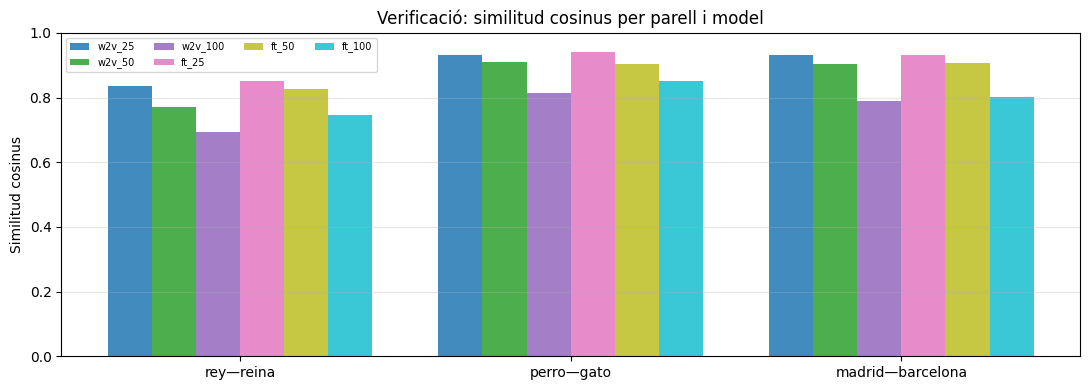

In [21]:
# ── Test de similituds ────────────────────────────────────────────────────
TEST_WORDS = [("rey", "reina"), ("perro", "gato"), ("madrid", "barcelona")]
rows = []
for key, model in {**W2V_MODELS, **FT_MODELS}.items():
    for w1, w2 in TEST_WORDS:
        try:
            sim = model.wv.similarity(w1, w2)
            rows.append({"Model": key, "Par": f"{w1}—{w2}", "Sim": round(sim, 3)})
        except KeyError:
            rows.append({"Model": key, "Par": f"{w1}—{w2}", "Sim": "OOV"})

sim_df = pd.DataFrame(rows)
print(sim_df.to_string(index=False))

plot_df = sim_df[sim_df["Sim"] != "OOV"].copy()
plot_df["Sim"] = plot_df["Sim"].astype(float)
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    models_list = list({**W2V_MODELS, **FT_MODELS}.keys())
    x = np.arange(len(TEST_WORDS))
    width = 0.8 / len(models_list)
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_list)))
    for i, (key, color) in enumerate(zip(models_list, colors)):
        vals = []
        for w1, w2 in TEST_WORDS:
            r = plot_df[(plot_df["Model"]==key) & (plot_df["Par"]==f"{w1}—{w2}")]
            vals.append(r["Sim"].values[0] if not r.empty else 0)
        ax.bar(x + i*width - 0.4 + width/2, vals, width, label=key, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f"{w1}—{w2}" for w1,w2 in TEST_WORDS])
    ax.set_ylabel("Similitud cosinus"); ax.set_ylim(0,1)
    ax.set_title("Verificació: similitud cosinus per parell i model")
    ax.legend(fontsize=7, ncol=4); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


---
## 9. Funcions d'accés als embeddings (API per a Parts 2 i 3)

In [22]:
def get_word_vector(word: str, model_key: str) -> Optional[np.ndarray]:
    """
    Retorna el vector d'una paraula per a un model determinat.
    model_key: 'w2v_25','w2v_50','w2v_100','ft_25','ft_50','ft_100','ft_official'
    Retorna None si la paraula no es troba (W2V OOV).
    """
    if model_key == "ft_official":
        if FT_OFFICIAL is None:
            return None
        # load_facebook_model retorna un objecte FastText de gensim amb .wv,
        # que pot generar vectors OOV a partir dels n-grames de caràcters.
        if hasattr(FT_OFFICIAL, "wv"):                         # gensim FastText (.bin)
            return FT_OFFICIAL.wv.get_vector(word, norm=False).astype(np.float32)
        elif hasattr(FT_OFFICIAL, "get_word_vector"):          # llibreria fasttext nativa
            return FT_OFFICIAL.get_word_vector(word).astype(np.float32)
        elif hasattr(FT_OFFICIAL, "__getitem__"):              # KeyedVectors (.vec, sense OOV)
            try:
                return FT_OFFICIAL[word]
            except KeyError:
                return None
        return None

    if model_key in W2V_MODELS:
        m = W2V_MODELS[model_key]
        return m.wv[word] if word in m.wv else None

    if model_key in FT_MODELS:
        return FT_MODELS[model_key].wv.get_vector(word, norm=False)

    if model_key in W2V_CORPUS:
        m = W2V_CORPUS[model_key]
        return m.wv[word] if word in m.wv else None

    if model_key in FT_CORPUS:
        return FT_CORPUS[model_key].wv.get_vector(word, norm=False)

    # Suport per a models del grid search
    for d in Path(CONFIG["models_dir"]).glob("*.model"):
        key_from_file = d.stem
        if key_from_file == model_key:
            # Intentem carregar-lo
            pass

    raise ValueError(f"Model desconegut: '{model_key}'. "
                     f"Opcions: {list(W2V_MODELS) + list(FT_MODELS) + list(W2V_CORPUS) + list(FT_CORPUS) + ['ft_official']}")


def get_sentence_vector(
    tokens: List[str],
    model_key: str,
    weights: Optional[np.ndarray] = None,
) -> Optional[np.ndarray]:
    """
    Representa una frase com la mitjana (simple o ponderada amb TF-IDF) dels seus vectors.
    """
    vecs, ws = [], []
    for i, token in enumerate(tokens):
        v = get_word_vector(token, model_key)
        if v is not None:
            vecs.append(v)
            ws.append(weights[i] if weights is not None else 1.0)
    if not vecs:
        return None
    vecs_arr = np.array(vecs)
    ws_arr   = np.array(ws, dtype=np.float32).reshape(-1, 1)
    ws_arr   = ws_arr / (ws_arr.sum() + 1e-9)
    return (vecs_arr * ws_arr).sum(axis=0)


def get_sentence_vector_full_corpus(
    tokens: List[str],
    model_key: str,
) -> Optional[np.ndarray]:
    """
    Versió alternativa: usa la mitjana simple però pot usar
    el model sobre tot el corpus (ft_official si disponible).
    Útil com a baseline fort sense TF-IDF.
    """
    return get_sentence_vector(tokens, model_key, weights=None)


def build_embedding_matrix(
    vocab: Dict[str, int],
    model_key: str,
    dim: int,
) -> np.ndarray:
    """
    Construeix la matriu d'embeddings per al model siamès BiLSTM (Part 3).
    Índex 0 → <PAD>, Índex 1 → <UNK>.
    """
    rng    = np.random.default_rng(CONFIG["seed"])
    matrix = np.zeros((len(vocab), dim), dtype=np.float32)
    matrix[1] = rng.normal(scale=0.01, size=dim)

    n_found, n_oov = 0, 0
    for word, idx in vocab.items():
        if idx <= 1:
            continue
        v = get_word_vector(word, model_key)
        if v is not None:
            matrix[idx] = v
            n_found += 1
        else:
            matrix[idx] = rng.normal(scale=0.01, size=dim)
            n_oov += 1

    coverage = n_found / (n_found + n_oov + 1e-9)
    print(f"[{model_key}] Matriu embeddings: {matrix.shape}  "
          f"cobertura={coverage:.1%}  OOV={n_oov:,}")
    return matrix


def is_oov(word: str, model_key: str) -> bool:
    # fastText (propi o oficial) mai té OOV: composa el vector amb n-grames.
    if model_key in FT_MODELS or model_key in FT_CORPUS or model_key == "ft_official":
        return False
    # Word2Vec: OOV si la paraula no és al vocabulari del model.
    if model_key in W2V_MODELS:
        return word not in W2V_MODELS[model_key].wv
    if model_key in W2V_CORPUS:
        return word not in W2V_CORPUS[model_key].wv
    raise ValueError(f"Model desconegut: {model_key}")


# ── Prova ─────────────────────────────────────────────────────────────────
print("Prova get_word_vector:")
v = get_word_vector("gato", "w2v_100")
print(f"  'gato' w2v_100 → {v[:5] if v is not None else 'OOV'}...")

print("\nProva get_sentence_vector:")
sv = get_sentence_vector(["el", "gato", "come"], "ft_100")
print(f"  'el gato come' ft_100 → {sv[:5] if sv is not None else 'Error'}...")

print("\nFuncions d'accés als embeddings llestes.")


Prova get_word_vector:
  'gato' w2v_100 → [ 0.10570432  0.03614071  0.11962759  0.12293452 -0.25332263]...

Prova get_sentence_vector:
  'el gato come' ft_100 → [ 0.13889748  0.17780888  0.3453189  -0.01238065  0.37309027]...

Funcions d'accés als embeddings llestes.


---
## Resum de variables exportades per a les Parts 2 i 3

| Variable / Funció | Tipus | Descripció |
|---|---|---|
| `CONFIG` | `dict` | Tota la configuració global |
| `W2V_MODELS` | `dict[str, Word2Vec]` | Models Word2Vec: `w2v_25`, `w2v_50`, `w2v_100` |
| `FT_MODELS` | `dict[str, GensimFastText]` | Models fastText (gensim): `ft_25`, `ft_50`, `ft_100` |
| `FT_OFFICIAL` | model o `None` | Model oficial Facebook (300d) |
| `SentenceIterator` | classe | Iterador perezós del corpus processat |
| `get_word_vector(word, model_key)` | funció | Vector d'una paraula |
| `get_sentence_vector(tokens, model_key, weights?)` | funció | Vector agregat (simple o TF-IDF) |
| `get_sentence_vector_full_corpus(tokens, model_key)` | funció | Vector agregat sense pes |
| `build_embedding_matrix(vocab, model_key, dim)` | funció | Matriu per al BiLSTM |
| `is_oov(word, model_key)` | funció | Comprova si una paraula és OOV |

**Com usar-lo des d'un altre notebook:**
```python
%run practica4_part1_embeddings.ipynb
```


---
---
# Part 2: Avaluació Intrínseca (Multi-SimLex)

**Objectiu**: Avaluar els embeddings sobre parells de paraules usant la correlació de Spearman.

## Índex Part 2
1. [Càrrega de Multi-SimLex](#p2-1-càrrega-de-multi-simlex)
2. [Funció d'avaluació intrínseca](#p2-2-funció-devaluació)
3. [Avaluació de tots els models](#p2-3-avaluació-de-tots-els-models)
4. [Anàlisi OOV](#p2-4-anàlisi-oov)
5. [Taula de resultats i gràfics](#p2-5-taula-i-gràfics)


---
### P2-2. Funció d'avaluació intrínseca

In [23]:
from scipy.stats import spearmanr
from numpy.linalg import norm as np_norm

def cosine_sim_np(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = np_norm(a), np_norm(b)
    if na < 1e-10 or nb < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def evaluate_intrinsic(
    model_key: str,
    df: pd.DataFrame,
) -> Dict:
    """
    Avalua un model sobre Multi-SimLex.
    Retorna un diccionari amb: model, spearman_rho, n_pairs, n_oov, oov_ratio.
    """
    if df is None or df.empty:
        return {"model": model_key, "spearman_rho": float("nan"),
                "n_pairs": 0, "n_oov": 0, "oov_ratio": float("nan")}

    preds, golds, oov_pairs = [], [], 0
    oov_words = set()

    for _, row in df.iterrows():
        w1, w2, gold = row["word1"], row["word2"], row["score"]
        v1 = get_word_vector(w1, model_key)
        v2 = get_word_vector(w2, model_key)

        if v1 is None or v2 is None:
            oov_pairs += 1
            if v1 is None: oov_words.add(w1)
            if v2 is None: oov_words.add(w2)
            continue

        preds.append(cosine_sim_np(v1, v2))
        golds.append(gold)

    n_total = len(df)
    oov_ratio = oov_pairs / n_total if n_total > 0 else 0

    if len(preds) < 5:
        rho = float("nan")
    else:
        rho, _ = spearmanr(golds, preds)

    return {
        "model"       : model_key,
        "spearman_rho": round(rho, 4) if not np.isnan(rho) else float("nan"),
        "n_pairs"     : len(preds),
        "n_oov"       : oov_pairs,
        "oov_ratio"   : round(oov_ratio, 3),
    }


---
### P2-3. Avaluació de tots els models

In [24]:
# ── Llista de models a avaluar ───────────────────────────────────────────
# Incloem tant els models per dimensió com els de mida de corpus
models_to_eval = list(W2V_MODELS.keys()) + list(FT_MODELS.keys())
models_to_eval += list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys())
if FT_OFFICIAL is not None:
    models_to_eval.append("ft_official")

print(f"Avaluant {len(models_to_eval)} models sobre Multi-SimLex...")

intrinsic_results = []
for key in tqdm(models_to_eval, desc="Avaluació intrínseca"):
    res = evaluate_intrinsic(key, simlex_df)
    intrinsic_results.append(res)
    status = f"ρ={res['spearman_rho']:.4f}" if not np.isnan(res['spearman_rho']) else "N/A"
    print(f"  {key:<22}: {status}  OOV={res['oov_ratio']:.1%}")

intrinsic_df = pd.DataFrame(intrinsic_results).sort_values("spearman_rho", ascending=False)


Avaluant 13 models sobre Multi-SimLex...


Avaluació intrínseca:   8%|▊         | 1/13 [00:00<00:07,  1.67it/s]

  w2v_25                : ρ=0.3503  OOV=6.4%


Avaluació intrínseca:  15%|█▌        | 2/13 [00:01<00:06,  1.63it/s]

  w2v_50                : ρ=0.3737  OOV=6.4%


...

  ft_10%                : ρ=0.2963  OOV=0.0%


Avaluació intrínseca:  85%|████████▍ | 11/13 [00:10<00:02,  1.23s/it]

  ft_50%                : ρ=0.3648  OOV=0.0%


Avaluació intrínseca: 100%|██████████| 13/13 [00:11<00:00,  1.14it/s]

  ft_100%               : ρ=0.3836  OOV=0.0%
  ft_official           : ρ=0.5034  OOV=0.0%


---
### P2-4. Anàlisi OOV

In [25]:
# ── Anàlisi detallada de les paraules OOV ────────────────────────────────
if simlex_df is not None:
    all_words = set(simlex_df["word1"].tolist() + simlex_df["word2"].tolist())
    print(f"Vocabulari de Multi-SimLex: {len(all_words)} paraules úniques\n")

    oov_table = []
    for key in models_to_eval:
        oov_words = [w for w in all_words if is_oov(w, key)]
        oov_table.append({
            "model"     : key,
            "vocab_size": (len(W2V_MODELS[key].wv) if key in W2V_MODELS
                           else (len(FT_MODELS[key].wv) if key in FT_MODELS
                                 else "—")),
            "oov_count" : len(oov_words),
            "oov_pct"   : f"{len(oov_words)/len(all_words):.1%}",
            "oov_examples": ", ".join(oov_words[:5]) if oov_words else "cap",
        })

    oov_df = pd.DataFrame(oov_table)
    print("Anàlisi OOV:")
    print(oov_df.to_string(index=False))
    print()
    print("[INFO] fastText genera vectors per a qualsevol paraula (0% OOV),")
    print("       Word2Vec no pot representar paraules fora del vocabulari d'entrenament.")


Vocabulari de Multi-SimLex: 2062 paraules úniques

Anàlisi OOV:
      model vocab_size  oov_count oov_pct                                                               oov_examples
     w2v_25     300250         93    4.5% bombardeo aéreo, darse cuenta de, a menudo, chocarse con, hacer senderismo
     w2v_50     300250         93    4.5% bombardeo aéreo, darse cuenta de, a menudo, chocarse con, hacer senderismo
    w2v_100     300250         93    4.5% bombardeo aéreo, darse cuenta de, a menudo, chocarse con, hacer senderismo
      ft_25     300250          0    0.0%                                                                        cap
      ft_50     300250          0    0.0%                                                                        cap
     ft_100     300250          0    0.0%                                                                        cap
    w2v_10%          —        223   10.8%              subrutina, bombardeo aéreo, darse cuenta de, pecador, empapar


---
### P2-5. Taula de resultats i gràfics

AVALUACIÓ INTRÍNSECA — Multi-SimLex (Spearman ρ)
      model  spearman_rho  n_pairs  n_oov  oov_ratio
ft_official        0.5034     1888      0      0.000
   w2v_100%        0.3972     1767    121      0.064
    w2v_100        0.3972     1767    121      0.064
     ft_100        0.3836     1888      0      0.000
    ft_100%        0.3836     1888      0      0.000
    w2v_50%        0.3774     1749    139      0.074
     w2v_50        0.3737     1767    121      0.064
      ft_50        0.3675     1888      0      0.000
     ft_50%        0.3648     1888      0      0.000
     w2v_25        0.3503     1767    121      0.064
      ft_25        0.3484     1888      0      0.000
    w2v_10%        0.3107     1621    267      0.141
     ft_10%        0.2963     1888      0      0.000



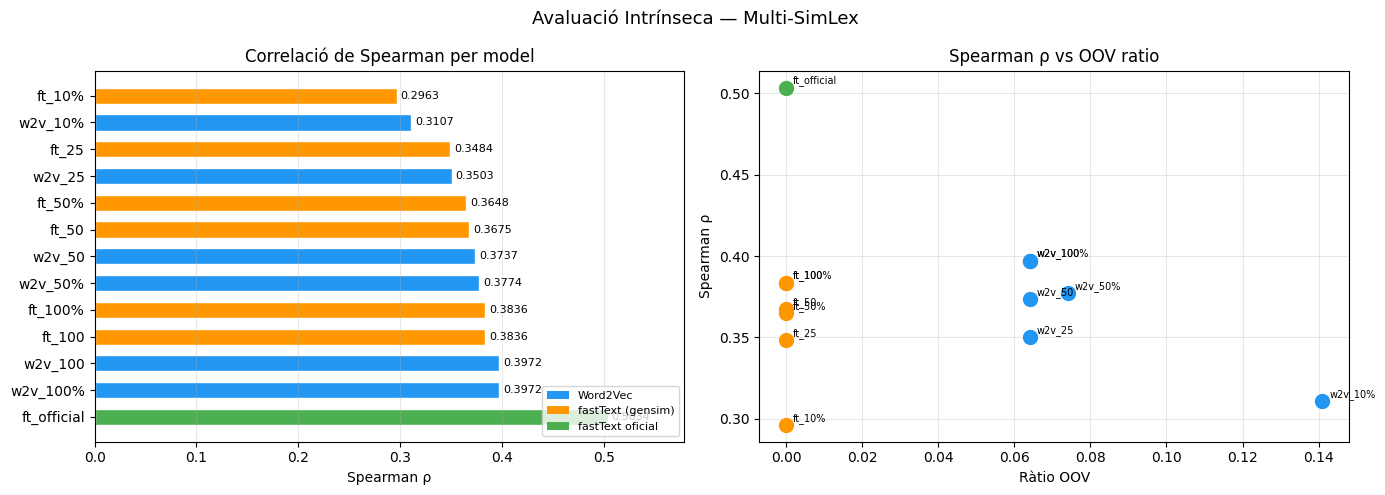

In [26]:
# ── Taula de resultats ────────────────────────────────────────────────────
print("=" * 60)
print("AVALUACIÓ INTRÍNSECA — Multi-SimLex (Spearman ρ)")
print("=" * 60)
print(intrinsic_df.to_string(index=False))
print()

# ── Gràfic barres: Spearman ρ per model ──────────────────────────────────
valid_df = intrinsic_df.dropna(subset=["spearman_rho"])

if not valid_df.empty:
    # Paleta: W2V en blau, FT-gensim en taronja, FT-oficial en verd
    def model_color(name):
        if "official" in name: return "#4CAF50"
        if name.startswith("ft"): return "#FF9800"
        return "#2196F3"

    colors = [model_color(m) for m in valid_df["model"]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Avaluació Intrínseca — Multi-SimLex", fontsize=13)

    # Gràfic 1: ρ per model
    ax = axes[0]
    bars = ax.barh(valid_df["model"], valid_df["spearman_rho"],
                   color=colors, edgecolor="white", height=0.6)
    ax.set_xlabel("Spearman ρ")
    ax.set_title("Correlació de Spearman per model")
    ax.set_xlim(0, max(valid_df["spearman_rho"].max() * 1.15, 0.1))
    ax.axvline(0, color="black", lw=0.5)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.grid(axis="x", alpha=0.3)

    # Llegenda manual
    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor="#2196F3", label="Word2Vec"),
        Patch(facecolor="#FF9800", label="fastText (gensim)"),
        Patch(facecolor="#4CAF50", label="fastText oficial"),
    ]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=8)

    # Gràfic 2: ρ vs OOV ratio
    ax2 = axes[1]
    for _, row in valid_df.iterrows():
        ax2.scatter(row["oov_ratio"], row["spearman_rho"],
                    color=model_color(row["model"]), s=100, zorder=3)
        ax2.annotate(row["model"], (row["oov_ratio"], row["spearman_rho"]),
                     textcoords="offset points", xytext=(5, 3), fontsize=7)
    ax2.set_xlabel("Ràtio OOV")
    ax2.set_ylabel("Spearman ρ")
    ax2.set_title("Spearman ρ vs OOV ratio")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No hi ha resultats vàlids per graficar (potser falta Multi-SimLex).")


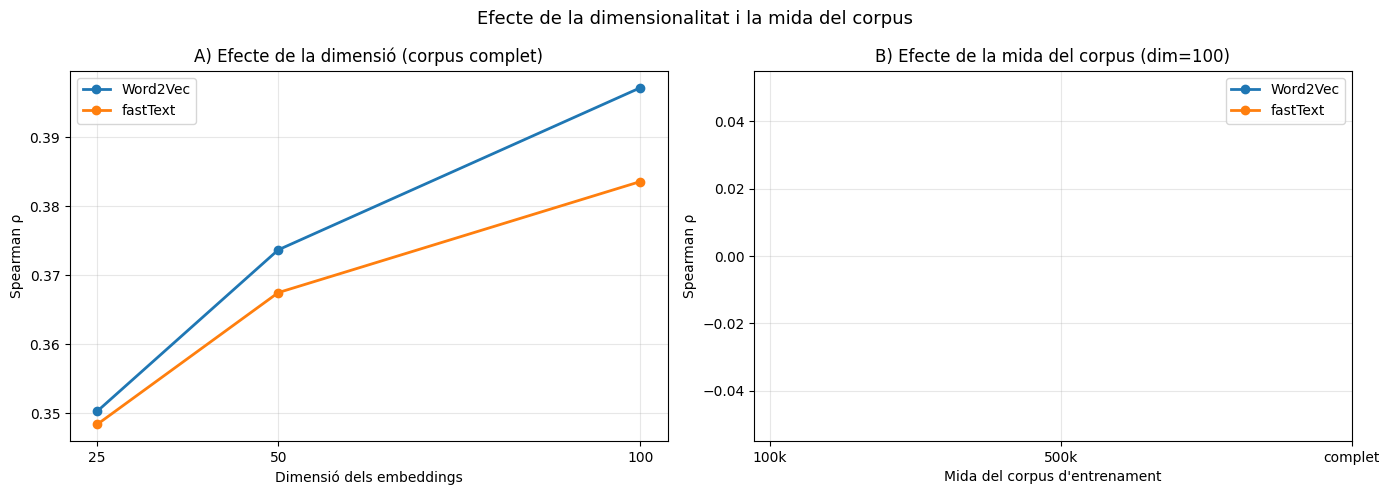

In [27]:
# ── Gràfic A: efecte de la dimensionalitat ───────────────────────────────
dim_df = intrinsic_df[intrinsic_df["model"].isin(
    list(W2V_MODELS.keys()) + list(FT_MODELS.keys())
)].copy()
dim_df["arch"] = dim_df["model"].apply(lambda x: "Word2Vec" if x.startswith("w") else "fastText")
dim_df["dim"]  = dim_df["model"].apply(lambda x: int(x.split("_")[1]))

# ── Gràfic B: efecte de la mida del corpus ───────────────────────────────
corpus_order = {"100k": 100_000, "500k": 500_000, "complet": None}
corpus_df = intrinsic_df[intrinsic_df["model"].isin(
    list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys())
)].copy()
corpus_df["arch"]  = corpus_df["model"].apply(lambda x: "Word2Vec" if x.startswith("w") else "fastText")
corpus_df["label"] = corpus_df["model"].apply(lambda x: x.split("_")[1])  # "100k","500k","complet"
corpus_df["size"]  = corpus_df["label"].map(corpus_order)

valid_dim    = dim_df.dropna(subset=["spearman_rho"])
valid_corpus = corpus_df.dropna(subset=["spearman_rho"])

if not valid_dim.empty or not valid_corpus.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Efecte de la dimensionalitat i la mida del corpus", fontsize=13)

    # Gràfic A
    ax = axes[0]
    if not valid_dim.empty:
        for arch, grp in valid_dim.groupby("arch"):
            grp = grp.sort_values("dim")
            ax.plot(grp["dim"], grp["spearman_rho"], marker="o", label=arch, linewidth=2)
        ax.set_xlabel("Dimensió dels embeddings")
        ax.set_ylabel("Spearman ρ")
        ax.set_title("A) Efecte de la dimensió (corpus complet)")
        ax.set_xticks(ALL_DIMS)
        ax.legend(); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Sense dades", ha="center", va="center", transform=ax.transAxes)

    # Gràfic B
    ax2 = axes[1]
    size_ticks = [100_000, 500_000]
    size_labels_plot = ["100k", "500k", "complet"]
    if not valid_corpus.empty:
        for arch, grp in valid_corpus.groupby("arch"):
            grp = grp.copy()
            grp["x"] = grp["label"].map({"100k":0,"500k":1,"complet":2})
            grp = grp.sort_values("x")
            ax2.plot(grp["x"], grp["spearman_rho"], marker="o", label=arch, linewidth=2)
        ax2.set_xticks([0,1,2])
        ax2.set_xticklabels(size_labels_plot)
        ax2.set_xlabel("Mida del corpus d'entrenament")
        ax2.set_ylabel("Spearman ρ")
        ax2.set_title(f"B) Efecte de la mida del corpus (dim={CORPUS_SIZE_DIM})")
        ax2.legend(); ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, "Sense dades", ha="center", va="center", transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()


---
---
# Part 3: Avaluació Extrínseca (Spanish STS)

**Objectiu**: Avaluar models per a la tasca de similitud semàntica de frases (STS) en espanyol.

## Models comparats
1. **Baseline cosinus** (mitjana simple i TF-IDF)
2. **Baseline cosinus amb ft_official** (corpus complet, si disponible)
3. **Model seqüencial siamès** (BiLSTM + atenció, embeddings estàtics)
4. **Model BERT siamès** (BETO: bert-base-spanish-wwm-cased)

## Mètrica: correlació de Pearson sobre el test set

## Índex Part 3
1. [Càrrega del dataset Spanish STS](#p3-1-dataset)
2. [Baseline cosinus](#p3-2-baseline)
3. [Vocabulari i tokenització](#p3-3-vocabulari)
4. [Model siamès BiLSTM](#p3-4-bilstm)
5. [Model BERT siamès (BETO)](#p3-5-bert)
6. [Taula resum i gràfics comparatius](#p3-6-resultats)


---
### P3-1. Càrrega del dataset Spanish STS

In [28]:
# Instal·la si cal: pip install datasets
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

print("Carregant Spanish STS...")
ds = load_dataset("PlanTL-GOB-ES/sts-es")

train_df = ds["train"].to_pandas().rename(columns={"label": "score"})
dev_df   = ds["dev"].to_pandas().rename(columns={"label": "score"})
test_df  = ds["test"].to_pandas().rename(columns={"label": "score"})

print(f"Claus disponibles: {list(ds.keys())}")
print(f"Train: {len(train_df)}  Dev: {len(dev_df)}  Test: {len(test_df)}")
print(f"Columnes: {list(train_df.columns)}")
print(train_df.head(3).to_string())

# Els scores estan en escala [0,5] → normalitzem a [0,1]
for df in [train_df, dev_df, test_df]:
    if df["score"].max() > 1.5:
        df["score"] = df["score"] / 5.0
print(f"\nScores normalitzats a [0,1]. Rang test: [{test_df['score'].min():.2f}, {test_df['score'].max():.2f}]")


Carregant Spanish STS...


2026-05-25 10:39:18,538 : WARNING : Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
c:\Natalia\Trabajo\Estudios\5_Inteligencia_Artificial\Q4\PLH\Practica-4-PLH\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nat\.cache\huggingface\hub\datasets--PlanTL-GOB-ES--sts-es. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://do

RuntimeError: Dataset scripts are no longer supported, but found sts-es.py

---
### P3-2. Baseline cosinus

In [ ]:
from scipy.stats import pearsonr

def tokenize_simple(text: str) -> List[str]:
    """Tokenització bàsica: minúscules i split per espai."""
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ ]", " ", text)
    return [t for t in text.split() if t]


def build_tfidf_weights(sentences: List[str]) -> Tuple:
    """Ajusta TF-IDF sobre una llista de frases i retorna (vectorizer, matrix)."""
    vec = TfidfVectorizer(use_idf=True, smooth_idf=True, norm=None, lowercase=True,
                          token_pattern=r"[a-záéíóúüñ]+")
    mat = vec.fit_transform(sentences)
    feat = np.array(vec.get_feature_names_out())
    return vec, mat, feat


def sentence_vector_tfidf(text: str, model_key: str, tfidf_row, feat_names) -> Optional[np.ndarray]:
    """Vector de frase amb pesos TF-IDF."""
    indices = tfidf_row.indices
    scores  = tfidf_row.data
    w_sum = np.zeros(
        W2V_MODELS[model_key].vector_size if model_key in W2V_MODELS
        else (FT_MODELS[model_key].vector_size if model_key in FT_MODELS else 300),
        dtype=np.float32
    )
    total_w = 0.0
    for idx, sc in zip(indices, scores):
        word = feat_names[idx]
        v = get_word_vector(word, model_key)
        if v is not None:
            w_sum  += sc * v
            total_w += sc
    if total_w < 1e-9:
        return get_sentence_vector(tokenize_simple(text), model_key)
    return w_sum / total_w


def evaluate_baseline_cosine(
    df: pd.DataFrame,
    model_key: str,
    use_tfidf: bool = False,
    tfidf_data: Tuple = None,
) -> float:
    """
    Avalua el baseline cosinus sobre df.
    Retorna Pearson r.
    """
    preds, golds = [], []

    if use_tfidf and tfidf_data is not None:
        _, tfidf_mat, feat_names = tfidf_data
        all_sents = list(df["sentence1"]) + list(df["sentence2"])
        # Necessitem reajustar TF-IDF per aquest subconjunt
        _vec, _mat, _feat = build_tfidf_weights(all_sents)

    for i, row in df.iterrows():
        s1 = str(row["sentence1"])
        s2 = str(row["sentence2"])
        gold = float(row["score"])

        if use_tfidf:
            all_s = [s1, s2]
            _vec2, _mat2, _feat2 = build_tfidf_weights(all_s)
            v1 = sentence_vector_tfidf(s1, model_key, _mat2[0], _feat2)
            v2 = sentence_vector_tfidf(s2, model_key, _mat2[1], _feat2)
        else:
            t1 = tokenize_simple(s1)
            t2 = tokenize_simple(s2)
            v1 = get_sentence_vector(t1, model_key)
            v2 = get_sentence_vector(t2, model_key)

        if v1 is None or v2 is None:
            preds.append(0.0)
        else:
            preds.append(cosine_sim_np(v1, v2))
        golds.append(gold)

    if len(set(preds)) < 2:
        return float("nan")
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


# ── Avaluació del baseline ────────────────────────────────────────────────
print("Avaluant baseline cosinus (test set)...\n")

baseline_results = []
for key in tqdm(models_to_eval, desc="Baseline cosinus"):
    r_simple = evaluate_baseline_cosine(test_df, key, use_tfidf=False)
    r_tfidf  = evaluate_baseline_cosine(test_df, key, use_tfidf=True)
    baseline_results.append({
        "model"         : key,
        "pearson_simple": r_simple,
        "pearson_tfidf" : r_tfidf,
    })
    print(f"  {key:<15}: simple={r_simple:.4f}  tfidf={r_tfidf:.4f}")

baseline_df = pd.DataFrame(baseline_results)


---
### P3-3. Vocabulari i tokenització per al model siamès

In [ ]:
# ── Construcció del vocabulari a partir del corpus STS ───────────────────
PAD_IDX = 0
UNK_IDX = 1
MIN_FREQ = 2

from collections import Counter

def build_vocab(sentences: List[str], min_freq: int = MIN_FREQ) -> Dict[str, int]:
    counter = Counter()
    for s in sentences:
        counter.update(tokenize_simple(s))
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab


all_sents = (
    list(train_df["sentence1"]) + list(train_df["sentence2"]) +
    list(dev_df["sentence1"])   + list(dev_df["sentence2"])
)
STS_VOCAB = build_vocab(all_sents, min_freq=MIN_FREQ)
print(f"Vocabulari STS: {len(STS_VOCAB):,} paraules (incl. PAD i UNK)")


def encode_sentence(tokens: List[str], vocab: Dict[str, int], max_len: int = 64) -> List[int]:
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:max_len]]
    # padding
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids


MAX_LEN = 64  # longitud màxima de seqüència

print(f"Max len: {MAX_LEN}")
print("Exemple:", encode_sentence(tokenize_simple("el gato come pescado"), STS_VOCAB)[:10], "...")


---
### P3-4. Model seqüencial siamès (BiLSTM + Atenció)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Dataset ───────────────────────────────────────────────────────────────
class STSDataset(Dataset):
    def __init__(self, df: pd.DataFrame, vocab: Dict[str, int], max_len: int = MAX_LEN):
        self.data   = df.reset_index(drop=True)
        self.vocab  = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        t1 = tokenize_simple(str(row["sentence1"]))
        t2 = tokenize_simple(str(row["sentence2"]))
        ids1 = encode_sentence(t1, self.vocab, self.max_len)
        ids2 = encode_sentence(t2, self.vocab, self.max_len)
        mask1 = [1 if i != PAD_IDX else 0 for i in ids1]
        mask2 = [1 if i != PAD_IDX else 0 for i in ids2]
        return (
            torch.tensor(ids1,  dtype=torch.long),
            torch.tensor(mask1, dtype=torch.bool),
            torch.tensor(ids2,  dtype=torch.long),
            torch.tensor(mask2, dtype=torch.bool),
            torch.tensor(float(row["score"]), dtype=torch.float),
        )


# ── Arquitectura ──────────────────────────────────────────────────────────
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha  = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix: np.ndarray,
                 hidden_size: int = 64, final_hidden_size: int = 32,
                 trainable_embeddings: bool = False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=PAD_IDX,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(emb_dim, hidden_size, batch_first=True,
                                bidirectional=True, dropout=0.2, num_layers=2)
        self.pool      = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(final_hidden_size, 1),
            nn.Sigmoid(),   # scores normalitzats [0,1]
        )

    def encode(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


# ── Entrenament ───────────────────────────────────────────────────────────
def train_siamese(
    model_key: str,
    trainable_emb: bool = False,
    hidden_size: int = 64,
    epochs: int = 10,
    lr: float = 1e-3,
    batch_size: int = 64,
    device: str = None,
) -> Tuple[nn.Module, List[float]]:
    """
    Entrena el model siamès BiLSTM.
    Retorna (model, llista de pearson_dev per època).
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Determinar dimensió
    if model_key in W2V_MODELS:
        dim = W2V_MODELS[model_key].vector_size
    elif model_key in FT_MODELS:
        dim = FT_MODELS[model_key].vector_size
    else:
        dim = CONFIG["fasttext_official_dim"]

    emb_matrix = build_embedding_matrix(STS_VOCAB, model_key, dim)
    model = SiameseBiLSTMAttention(
        emb_matrix, hidden_size=hidden_size,
        final_hidden_size=hidden_size // 2,
        trainable_embeddings=trainable_emb
    ).to(device)

    train_ds = STSDataset(train_df, STS_VOCAB)
    dev_ds   = STSDataset(dev_df,   STS_VOCAB)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_dl   = DataLoader(dev_ds,   batch_size=batch_size)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.MSELoss()

    dev_scores = []
    best_pearson, best_state = -1.0, None

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        total_loss = 0
        for batch in train_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss  = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        # ── Eval dev ──
        model.eval()
        all_preds, all_golds = [], []
        with torch.no_grad():
            for batch in dev_dl:
                ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
                preds = model(ids1, mask1, ids2, mask2).cpu().numpy()
                all_preds.extend(preds.tolist())
                all_golds.extend(labels.cpu().numpy().tolist())

        r, _ = pearsonr(all_golds, all_preds)
        dev_scores.append(r)
        scheduler.step(-r)
        if r > best_pearson:
            best_pearson = r
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  Época {epoch:2d}/{epochs}  loss={total_loss/len(train_dl):.4f}  "
              f"pearson_dev={r:.4f}  best={best_pearson:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return model, dev_scores


def eval_siamese_test(model, device=None) -> float:
    """Avalua el model sobre el test set. Retorna Pearson r."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval().to(device)
    test_ds = STSDataset(test_df, STS_VOCAB)
    test_dl = DataLoader(test_ds, batch_size=64)
    preds, golds = [], []
    with torch.no_grad():
        for batch in test_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            p = model(ids1, mask1, ids2, mask2).cpu().numpy()
            preds.extend(p.tolist())
            golds.extend(labels.cpu().numpy().tolist())
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


In [ ]:
# ── Execució dels experiments BiLSTM ─────────────────────────────────────
# Configuració d'experiments: (model_key, trainable_emb, label)
LSTM_EXPERIMENTS = [
    ("w2v_100", False, "W2V-100 frozen"),
    ("w2v_100", True,  "W2V-100 trainable"),
    ("ft_100",  False, "FT-100 frozen"),
    ("ft_100",  True,  "FT-100 trainable"),
]
# Si ft_official disponible, afegir-lo
if FT_OFFICIAL is not None:
    LSTM_EXPERIMENTS.append(("ft_official", False, "FT-oficial frozen"))

LSTM_EPOCHS = 10  # redueix si va lent (p.ex. 5)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

bilstm_results = []
bilstm_curves  = {}

for model_key, trainable, label in LSTM_EXPERIMENTS:
    print(f"\n══ Entrenant BiLSTM: {label} ══")
    try:
        trained_model, dev_curve = train_siamese(
            model_key=model_key,
            trainable_emb=trainable,
            epochs=LSTM_EPOCHS,
            device=DEVICE,
        )
        test_r = eval_siamese_test(trained_model, device=DEVICE)
        bilstm_results.append({"model": label, "pearson_test": test_r})
        bilstm_curves[label] = dev_curve
        print(f"  → Test Pearson: {test_r:.4f}")
    except Exception as e:
        print(f"  [ERROR] {e}")
        bilstm_results.append({"model": label, "pearson_test": float("nan")})

bilstm_df = pd.DataFrame(bilstm_results)
print("\nResultats BiLSTM:")
print(bilstm_df.to_string(index=False))


In [ ]:
# ── Corbes d'aprenentatge BiLSTM ──────────────────────────────────────────
if bilstm_curves:
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, curve in bilstm_curves.items():
        ax.plot(range(1, len(curve) + 1), curve, marker="o", label=label, linewidth=1.5)
    ax.set_xlabel("Època")
    ax.set_ylabel("Pearson r (dev)")
    ax.set_title("Corbes d'aprenentatge — BiLSTM Siamès")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


---
### P3-5. Model BERT siamès (BETO)

In [ ]:
from transformers import AutoTokenizer, AutoModel

BERT_MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO

# ── Arquitectura ──────────────────────────────────────────────────────────
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x    = last_hidden_state * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL_NAME,
                 final_hidden_size: int = 64):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        self.pool      = MeanPooling()
        hidden         = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
            nn.Sigmoid(),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


# ── Dataset BERT ──────────────────────────────────────────────────────────
class STSBertDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = 128):
        self.data      = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc1 = self.tokenizer(str(row["sentence1"]), max_length=self.max_len,
                              padding="max_length", truncation=True, return_tensors="pt")
        enc2 = self.tokenizer(str(row["sentence2"]), max_length=self.max_len,
                              padding="max_length", truncation=True, return_tensors="pt")
        return (
            enc1["input_ids"].squeeze(0),
            enc1["attention_mask"].squeeze(0),
            enc2["input_ids"].squeeze(0),
            enc2["attention_mask"].squeeze(0),
            torch.tensor(float(row["score"]), dtype=torch.float),
        )


In [ ]:
def train_bert_siamese(
    model_name: str = BERT_MODEL_NAME,
    epochs: int = 3,
    lr: float = 2e-5,
    batch_size: int = 16,
    max_len: int = 128,
    device: str = None,
) -> Tuple[nn.Module, List[float]]:
    """Entrena el model BERT siamès."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Carregant tokenizer i model BERT: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = BETOSiameseRegressor(model_name).to(device)

    train_ds = STSBertDataset(train_df, tokenizer, max_len)
    dev_ds   = STSBertDataset(dev_df,   tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_dl   = DataLoader(dev_ds,   batch_size=batch_size)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs * len(train_dl)
    )
    criterion = nn.MSELoss()

    dev_scores, best_pearson, best_state = [], -1.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in tqdm(train_dl, desc=f"Època {epoch}/{epochs}", leave=False):
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss  = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        model.eval()
        preds_dev, golds_dev = [], []
        with torch.no_grad():
            for batch in dev_dl:
                ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
                p = model(ids1, mask1, ids2, mask2).cpu().numpy()
                preds_dev.extend(p.tolist())
                golds_dev.extend(labels.cpu().numpy().tolist())

        r, _ = pearsonr(golds_dev, preds_dev)
        dev_scores.append(r)
        if r > best_pearson:
            best_pearson = r
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  Època {epoch}/{epochs}  loss={total_loss/len(train_dl):.4f}  pearson_dev={r:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return model, dev_scores


def eval_bert_test(model, tokenizer_name: str = BERT_MODEL_NAME, device=None) -> float:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model.eval().to(device)
    test_ds = STSBertDataset(test_df, tokenizer)
    test_dl = DataLoader(test_ds, batch_size=16)
    preds, golds = [], []
    with torch.no_grad():
        for batch in test_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            p = model(ids1, mask1, ids2, mask2).cpu().numpy()
            preds.extend(p.tolist())
            golds.extend(labels.cpu().numpy().tolist())
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


# ── Entrena BERT (descomenta per executar; requereix GPU o molta paciència) ──
BERT_EPOCHS = 3

print(f"Entrenant BETO Siamès ({BERT_EPOCHS} èpoques)...")
print("[NOTA] Amb CPU pot trigar molt. Recomanat GPU o Google Colab.")
try:
    bert_model, bert_dev_curve = train_bert_siamese(
        epochs=BERT_EPOCHS, device=DEVICE
    )
    bert_test_r = eval_bert_test(bert_model, device=DEVICE)
    print(f"\nBETO Siamès — Test Pearson: {bert_test_r:.4f}")
    bert_result = {"model": "BETO Siamès", "pearson_test": bert_test_r}
except Exception as e:
    print(f"[ERROR] No s'ha pogut entrenar BETO: {e}")
    bert_test_r = float("nan")
    bert_dev_curve = []
    bert_result = {"model": "BETO Siamès", "pearson_test": float("nan")}


---
### P3-6. Taula resum i gràfics comparatius

In [ ]:
# ══════════════════════════════════════════════════════════════
# TAULA RESUM COMPARATIVA — TOTES LES CONFIGURACIONS
# ══════════════════════════════════════════════════════════════

# 1. Baselines cosinus
all_results = []
for _, row in baseline_df.iterrows():
    all_results.append({
        "Sistema"  : f"Cosinus-Simple ({row['model']})",
        "Pearson r": row["pearson_simple"],
        "Categoria": "Baseline",
    })
    all_results.append({
        "Sistema"  : f"Cosinus-TF-IDF ({row['model']})",
        "Pearson r": row["pearson_tfidf"],
        "Categoria": "Baseline TF-IDF",
    })

# 2. BiLSTM
for _, row in bilstm_df.iterrows():
    all_results.append({
        "Sistema"  : f"BiLSTM ({row['model']})",
        "Pearson r": row["pearson_test"],
        "Categoria": "BiLSTM Siamès",
    })

# 3. BERT
all_results.append({
    "Sistema"  : "BETO Siamès",
    "Pearson r": bert_test_r,
    "Categoria": "BERT",
})

summary_df = pd.DataFrame(all_results).sort_values("Pearson r", ascending=False)
summary_df["Pearson r"] = summary_df["Pearson r"].round(4)

print("=" * 65)
print("RESUM COMPARATIU — Spanish STS (Pearson r, test set)")
print("=" * 65)
print(summary_df.to_string(index=False))


In [ ]:
# ── Gràfics comparatius ───────────────────────────────────────────────────
valid_summary = summary_df.dropna(subset=["Pearson r"])

if not valid_summary.empty:
    cat_colors = {
        "Baseline"      : "#90CAF9",
        "Baseline TF-IDF": "#42A5F5",
        "BiLSTM Siamès" : "#FF9800",
        "BERT"          : "#4CAF50",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Comparació de sistemes — Spanish STS (Pearson r)", fontsize=13)

    # Gràfic 1: totes les configuracions
    ax = axes[0]
    colors_list = [cat_colors.get(c, "#999") for c in valid_summary["Categoria"]]
    bars = ax.barh(valid_summary["Sistema"], valid_summary["Pearson r"],
                   color=colors_list, edgecolor="white", height=0.7)
    ax.set_xlabel("Pearson r")
    ax.set_title("Totes les configuracions")
    ax.set_xlim(0, min(valid_summary["Pearson r"].max() * 1.2, 1.0))
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=7)
    ax.axvline(0, color="black", lw=0.5)
    ax.grid(axis="x", alpha=0.3)

    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=c, label=k) for k, c in cat_colors.items()]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=8)

    # Gràfic 2: millor per categoria
    ax2 = axes[1]
    best_per_cat = valid_summary.groupby("Categoria")["Pearson r"].max().sort_values(ascending=True)
    colors2 = [cat_colors.get(c, "#999") for c in best_per_cat.index]
    bars2 = ax2.barh(best_per_cat.index, best_per_cat.values,
                     color=colors2, edgecolor="white", height=0.5)
    ax2.set_xlabel("Pearson r (millor per categoria)")
    ax2.set_title("Millor resultat per categoria")
    ax2.bar_label(bars2, fmt="%.4f", padding=3, fontsize=9)
    ax2.set_xlim(0, min(best_per_cat.max() * 1.2, 1.0))
    ax2.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── Gràfic progressió per categories ─────────────────────────────────────
category_order = ["Baseline", "Baseline TF-IDF", "BiLSTM Siamès", "BERT"]
best_per_cat_ordered = (
    valid_summary.groupby("Categoria")["Pearson r"].max()
    .reindex([c for c in category_order if c in valid_summary["Categoria"].values])
)

if len(best_per_cat_ordered) > 1:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(len(best_per_cat_ordered)), best_per_cat_ordered.values,
            marker="o", linewidth=2.5, markersize=10, color="#7B1FA2")
    for i, (cat, val) in enumerate(best_per_cat_ordered.items()):
        ax.annotate(f"{val:.4f}", (i, val), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9)
    ax.set_xticks(range(len(best_per_cat_ordered)))
    ax.set_xticklabels(best_per_cat_ordered.index, rotation=10)
    ax.set_ylabel("Pearson r")
    ax.set_title("Guany acumulat per complexitat del sistema")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Anàlisi final: discussió automàtica ───────────────────────────────────
print("=" * 65)
print("ANÀLISI DELS RESULTATS")
print("=" * 65)

if not valid_summary.empty:
    best_overall = valid_summary.iloc[0]
    print(f"\n✓ Millor sistema: {best_overall['Sistema']}")
    print(f"  Pearson r = {best_overall['Pearson r']:.4f}")

    # Guany BERT vs millor baseline
    best_baseline_r = valid_summary[valid_summary["Categoria"].str.startswith("Baseline")]["Pearson r"].max()
    bert_r = valid_summary[valid_summary["Categoria"] == "BERT"]["Pearson r"]
    if not bert_r.empty and not np.isnan(best_baseline_r):
        gain = bert_r.values[0] - best_baseline_r
        print(f"\n✓ Guany BERT vs millor baseline: +{gain:.4f} ({gain/best_baseline_r*100:.1f}%)")

    # Guany BiLSTM vs baseline simple
    best_bilstm = valid_summary[valid_summary["Categoria"] == "BiLSTM Siamès"]["Pearson r"]
    if not best_bilstm.empty and not np.isnan(best_baseline_r):
        gain2 = best_bilstm.max() - best_baseline_r
        print(f"✓ Guany BiLSTM vs millor baseline: +{gain2:.4f}")

    # Efecte TF-IDF
    simple_vals = valid_summary[valid_summary["Categoria"] == "Baseline"]["Pearson r"]
    tfidf_vals  = valid_summary[valid_summary["Categoria"] == "Baseline TF-IDF"]["Pearson r"]
    if not simple_vals.empty and not tfidf_vals.empty:
        diff = tfidf_vals.mean() - simple_vals.mean()
        sign = "+" if diff >= 0 else ""
        print(f"✓ Efecte TF-IDF (mitjana): {sign}{diff:.4f}")

print("\n[FI] Pràctica 4 completada.")
